# CMIP6 Models - Identify the start and end of Spring and Autumn based on the onset/wthdrawal days of Summer and Winter: 1961-2025+

## some things to sort out
- if winter has length zero then when does fall end and also when does spring start
- spring and autumn start in the same calendar year as summer in NH but in the SH spring and autumn are in the same calendar year as winter

### So SH's 1991 autumn actually occurred in calendar year 1992

## Load libraries

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

import matplotlib.ticker as mticker
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

import pymannkendall as mk

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

# CanESM5 SSP2-4.5 Testing

## pull in summer data

In [7]:
ds_canesm5_summ = xr.open_dataset('../../../../Data/CMIP6/CanESM5/Summers-SSP2-45/1990-2099_ALL_summer_stats.nc')

# drop unneeded vars
ds_canesm5_summ = ds_canesm5_summ.drop_vars(["SummerTmax","SummerRMSE","SummerR2","SummerMeanT","SummerMeanHS","SummerHeat"])
ds_canesm5_summ

<xarray.Dataset> Size: 22MB
Dimensions:       (time: 110, lat: 64, lon: 128)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
  * lat           (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon           (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
Data variables:
    SummerStart   (time, lat, lon) float64 7MB ...
    SummerEnd     (time, lat, lon) float64 7MB ...
    SummerLength  (time, lat, lon) float64 7MB ...

## pull in winter data

In [10]:
list(ds_canesm5_wint.data_vars)

['WinterStart',
 'WinterEnd',
 'WinterTmax',
 'WinterCold',
 'WinterLength',
 'WinterlikeDays',
 'WinterRMSE',
 'WinterMeanT',
 'lat_bnds',
 'lon_bnds',
 'sftlf']

In [14]:
ds_canesm5_wint = xr.open_dataset('../../../../Data/CMIP6/CanESM5/Winters-SSP2-45/1990-2099_ALL_winter_stats.nc')
ds_canesm5_wint = ds_canesm5_wint.drop_vars(['WinterTmax',
 'WinterCold',
 'WinterlikeDays',
 'WinterRMSE',
 'WinterMeanT',
 'lat_bnds',
 'lon_bnds'])
#ds_canesm5_wint = ds_canesm5_wint.drop_dims(["type"])
ds_canesm5_wint

<xarray.Dataset> Size: 25MB
Dimensions:       (time: 110, lat: 64, lon: 128)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
  * lat           (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon           (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    type          |S4 4B ...
Data variables:
    WinterStart   (time, lat, lon) float64 7MB ...
    WinterEnd     (time, lat, lon) float64 7MB ...
    WinterLength  (time, lat, lon) float64 7MB ...
    sftlf         (time, lat, lon) float32 4MB ...

## Can subtract $Winter_{start} - Summer_{end}$ to get Autumn in NH but need to remember that $Winter_{start}$ is based on a July 1 - June 30 year, so have to include an offset of 182 (or 183?). Similarly for SH Spring...

## Two year's time series with seasons - Vancouver 2070 (actually on Van Island because of coarse resolution)

In [140]:
#test for Vancouver
input_lat = 49.25
input_lon = -123
van_sum = ds_canesm5_summ.sel(lat=input_lat, lon=input_lon, method="nearest")
van_win = ds_canesm5_wint.sel(lat=input_lat, lon=input_lon, method="nearest")

In [141]:
ds_tmp = van_sum.merge(van_win)
ds_tmp

<xarray.Dataset> Size: 7kB
Dimensions:       (time: 110)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
    lat           float64 8B 48.84
    lon           float64 8B -123.8
    type          |S4 4B ...
Data variables:
    SummerStart   (time) float64 880B ...
    SummerEnd     (time) float64 880B ...
    SummerLength  (time) float64 880B ...
    WinterStart   (time) float64 880B ...
    WinterEnd     (time) float64 880B ...
    WinterLength  (time) float64 880B ...
    sftlf         (time) float32 440B ...

In [142]:
%%time


file_path = '../../../../Data/CMIP6/CanESM5/FixedCoords/tas_day_CanESM5_ssp245_r1i1p1f1_gn_20150101-21001231.nc'
ds = xr.open_mfdataset(file_path)

ds_2070 = ds.sel(time='2070')
ds_2071 = ds.sel(time='2071')

# update time variable
ds_2070['time'] = ds_2070.indexes['time'].to_datetimeindex()
ds_2071['time'] = ds_2071.indexes['time'].to_datetimeindex()

#test for Vancouver
curr = ds_2070.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = ds_2071.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
ds_two = xr.concat([curr, nxt], dim="time")

CPU times: user 67.7 ms, sys: 27.8 ms, total: 95.5 ms
Wall time: 96.9 ms


In [143]:
ds_two

<xarray.DataArray 'tas' (time: 730)> Size: 3kB
dask.array<concatenate, shape=(730,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 6kB 2070-01-01T12:00:00 ... 2071-12-31T12:...
    lon      float64 8B -123.8
    lat      float64 8B 48.84
    height   float64 8B ...
Attributes:
    standard_name:     air_temperature
    long_name:         Near-Surface Air Temperature
    units:             K
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  32
    comment:           near-surface (usually, 2 meter) air temperature
    original_name:     ST
    cell_methods:      area: time: mean
    cell_measures:     area: areacella
    history:           2019-05-02T08:38:26Z altered by CMOR: Treated scalar d...

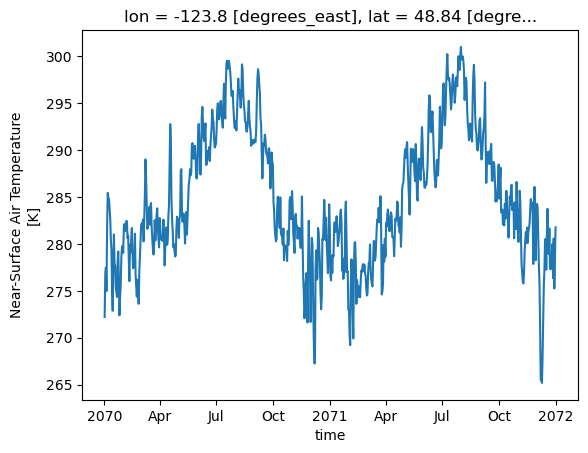

In [144]:
ds_two.plot()

### get baseline summer and winter temps to add to plot

In [145]:
# get baseline summer and winter temps
file_path_25 = '../../../../Data/CMIP6/CanESM5/FixedCoords/baseline/computed_1961-1990-full_25th.nc'
file_path_75 = '../../../../Data/CMIP6/CanESM5/FixedCoords/baseline/computed_1961-1990-full_75th.nc'
c_25 = xr.open_dataarray(file_path_25)
c_75 = xr.open_dataarray(file_path_75)
c_25_tmp = c_25.sel(lat=input_lat, lon=input_lon, method="nearest")
c_75_tmp = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")

### Plot Vancouver Time Series 
with thresholds

In [146]:
ds_two['DaysSince2070_01_01'] = (ds_two.time - np.datetime64('2070-01-01')).dt.days + 1
ds_two

<xarray.DataArray 'tas' (time: 730)> Size: 3kB
dask.array<concatenate, shape=(730,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time                 (time) datetime64[ns] 6kB 2070-01-01T12:00:00 ... 20...
    lon                  float64 8B -123.8
    lat                  float64 8B 48.84
    height               float64 8B ...
    DaysSince2070_01_01  (time) int64 6kB 1 2 3 4 5 6 ... 726 727 728 729 730
Attributes:
    standard_name:     air_temperature
    long_name:         Near-Surface Air Temperature
    units:             K
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  32
    comment:           near-surface (usually, 2 meter) air temperature
    original_name:     ST
    cell_methods:      area: time: mean
    cell_measures:     area: areacella
    history:           2019-05-02T08:38:26Z altered by CMOR: Treated scalar d...

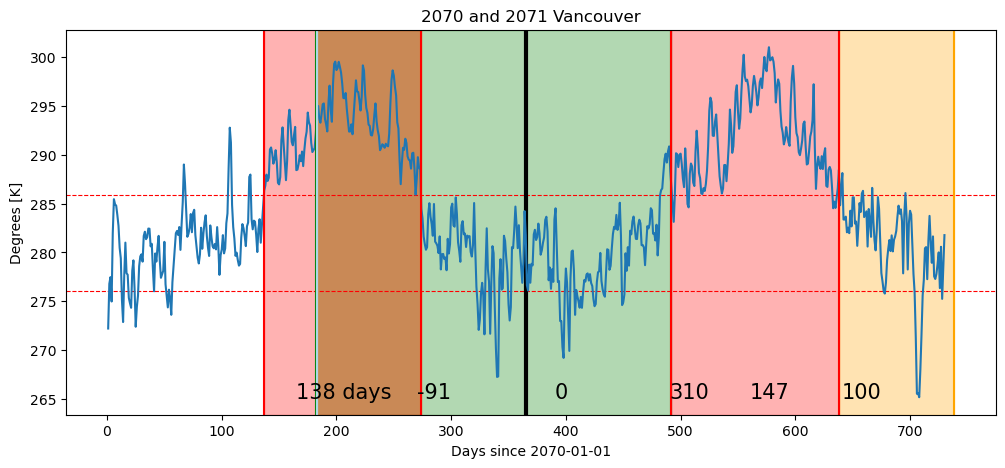

In [147]:
plt.figure(figsize=(12,5))

plt.axhline(c_25_tmp.values, color="red", linewidth=0.8, linestyle="dashed") 
plt.axhline(c_75_tmp.values, color="red", linewidth=0.8, linestyle="dashed") 
plt.axvline(365, color="black", linewidth=3)
plt.plot(ds_two.DaysSince2070_01_01, ds_two.values)
#plt.plot(ds_two.time, ds_two.values)

# put in the start end days that I calculated above for springs and autumns
# 2070 autumn
plt.axvline(ds_tmp.sel(time='2070').SummerEnd.values, color="orange")
plt.axvline(ds_tmp.sel(time='2070').WinterStart.values+183, color="orange")
plt.axvspan(ds_tmp.sel(time='2070').SummerEnd.values[0],
            (ds_tmp.sel(time='2070').WinterStart.values+183)[0], color='orange', alpha=0.3)

# 2071 spring
plt.axvline(ds_tmp.sel(time='2071').SummerStart.values + 365, color="green")
plt.axvline((ds_tmp.sel(time='2070').WinterEnd.values - 183)+365, color="green")
plt.axvspan(((ds_tmp.sel(time='2070').WinterEnd.values - 183)+365)[0],
            (ds_tmp.sel(time='2071').SummerStart.values + 365)[0], color='green', alpha=0.3)

# 2071 autumn following logic above
plt.axvline(ds_tmp.sel(time='2071').SummerEnd.values + 365, color="orange")
plt.axvline(ds_tmp.sel(time='2071').WinterStart.values+183 + 365, color="orange")
plt.axvspan(ds_tmp.sel(time='2071').SummerEnd.values[0] + 365,
            (ds_tmp.sel(time='2071').WinterStart.values+183)[0] + 365, color='orange', alpha=0.3)

# 2070 summer is all in 2070
plt.axvline(ds_tmp.sel(time='2070').SummerStart.values, color="red")
plt.axvline(ds_tmp.sel(time='2070').SummerEnd.values, color="red")
plt.axvspan(ds_tmp.sel(time='2070').SummerStart.values[0],
            ds_tmp.sel(time='2070').SummerEnd.values[0], color='red', alpha=0.3)

# 2071 summer is all in 2071
plt.axvline(ds_tmp.sel(time='2071').SummerStart.values + 365, color="red")
plt.axvline(ds_tmp.sel(time='2071').SummerEnd.values + 365, color="red")
plt.axvspan(ds_tmp.sel(time='2071').SummerStart.values[0] + 365,
            ds_tmp.sel(time='2071').SummerEnd.values[0] + 365, color='red', alpha=0.3)

# 2070 winter spans two calendar years
plt.axvline(ds_tmp.sel(time='2070').WinterStart.values + 183, color="lightblue")
plt.axvline(ds_tmp.sel(time='2070').WinterEnd.values + 183, color="lightblue")
plt.axvspan((ds_tmp.sel(time='2070').WinterStart.values + 183)[0],
            (ds_tmp.sel(time='2070').WinterEnd.values + 183)[0], color='lightblue', alpha=0.3)


# annotations
# summers and winter are easy
plt.annotate(str(int(ds_tmp.sel(time='2070').SummerLength.values[0]))+' days', xy=(165, 265), rotation=0, fontsize=15)
plt.annotate(int(ds_tmp.sel(time='2071').SummerLength.values[0]), xy=(560, 265), rotation=0, fontsize=15)
plt.annotate(int(ds_tmp.sel(time='2070').WinterLength.values[0]), xy=(390, 265), rotation=0, fontsize=15)

# spring 2071
plt.annotate(int((ds_tmp.sel(time='2071').SummerStart.values - (ds_tmp.sel(time='2070').WinterEnd.values - 183))[0]), xy=(490, 265), rotation=0, fontsize=15)

# autumn 2070
plt.annotate(int((ds_tmp.sel(time='2070').WinterStart.values+183)[0] - ds_tmp.sel(time='2070').SummerEnd.values[0]), xy=(270,265), rotation=0, fontsize=15)

# autumn 2071
plt.annotate(int((ds_tmp.sel(time='2071').WinterStart.values+183)[0] - ds_tmp.sel(time='2071').SummerEnd.values[0]), xy=(640,265), rotation=0, fontsize=15)

plt.title("2070 and 2071 Vancouver")
plt.xlabel("Days since 2070-01-01")
plt.ylabel("Degrees [K]")
plt.show()

## So having zero length winter can cause overlap in seasons that prob should get handled - will take note

## Process all years, all season lengths - add spring and autumn length

In [15]:
ds_canesm5_seasons = ds_canesm5_wint.merge(ds_canesm5_summ)
ds_canesm5_seasons

<xarray.Dataset> Size: 47MB
Dimensions:       (time: 110, lat: 64, lon: 128)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
  * lat           (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon           (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    type          |S4 4B ...
Data variables:
    WinterStart   (time, lat, lon) float64 7MB ...
    WinterEnd     (time, lat, lon) float64 7MB ...
    WinterLength  (time, lat, lon) float64 7MB ...
    sftlf         (time, lat, lon) float32 4MB ...
    SummerStart   (time, lat, lon) float64 7MB ...
    SummerEnd     (time, lat, lon) float64 7MB ...
    SummerLength  (time, lat, lon) float64 7MB ...

In [16]:
# set spring and autumn lengths to zero initially but ensure they have coordinates
ds_canesm5_seasons['SpringLength'] = ds_canesm5_seasons.SummerLength - ds_canesm5_seasons.SummerLength
ds_canesm5_seasons['AutumnLength'] = ds_canesm5_seasons.SummerLength - ds_canesm5_seasons.SummerLength
ds_canesm5_seasons

<xarray.Dataset> Size: 61MB
Dimensions:       (time: 110, lat: 64, lon: 128)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
  * lat           (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon           (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    type          |S4 4B ...
Data variables:
    WinterStart   (time, lat, lon) float64 7MB ...
    WinterEnd     (time, lat, lon) float64 7MB ...
    WinterLength  (time, lat, lon) float64 7MB ...
    sftlf         (time, lat, lon) float32 4MB ...
    SummerStart   (time, lat, lon) float64 7MB ...
    SummerEnd     (time, lat, lon) float64 7MB ...
    SummerLength  (time, lat, lon) float64 7MB ...
    SpringLength  (time, lat, lon) float64 7MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    AutumnLength  (time, lat, lon) float64 7MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

### split by hemisphere since we process each differently

In [17]:
# split by hemisphere since we process each differently
nh = ds_canesm5_seasons.sel(lat=slice(0,90))
sh = ds_canesm5_seasons.sel(lat=slice(-90,-0.25))

In [18]:
ds_canesm5_seasons['SpringLength'].sel(lat=slice(0,90))

<xarray.DataArray 'SpringLength' (time: 110, lat: 32, lon: 128)> Size: 4MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(110, 32, 128))
Coordinates:
  * time     (time) datetime64[ns] 880B 1990-01-01 1991-01-01 ... 2099-01-01
  * lat      (lat) float64 256B 1.395 4.186 6.977 9.767 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB -180.0 -177.2 -174.4 -171.6 ... 171.6 174.4 177.2
    type     |S4 4B ...

### SH Springs are easy

In [19]:
# SH springs are easy
# springstart = (ds_tmp_syd.sel(time=str(year)).WinterEnd.values[0])
# springend = (ds_tmp_syd.sel(time=str(year)).SummerStart.values + 183)[0]
# springlength = int(springend - springstart)
sh['SpringLength'] = (sh.SummerStart + 183) - sh.WinterEnd
sh

<xarray.Dataset> Size: 31MB
Dimensions:       (time: 110, lat: 32, lon: 128)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
  * lat           (lat) float64 256B -87.86 -85.1 -82.31 ... -4.186 -1.395
  * lon           (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    type          |S4 4B ...
Data variables:
    WinterStart   (time, lat, lon) float64 4MB ...
    WinterEnd     (time, lat, lon) float64 4MB ...
    WinterLength  (time, lat, lon) float64 4MB ...
    sftlf         (time, lat, lon) float32 2MB ...
    SummerStart   (time, lat, lon) float64 4MB 140.0 140.0 140.0 ... 1.0 1.0 1.0
    SummerEnd     (time, lat, lon) float64 4MB ...
    SummerLength  (time, lat, lon) float64 4MB ...
    SpringLength  (time, lat, lon) float64 4MB 64.0 63.0 63.0 ... 184.0 184.0
    AutumnLength  (time, lat, lon) float64 4MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [20]:
# check Sydney 1961 and 1962 to confirm
syd_lat = -33 - 52/60 - 4/3600
syd_lon = 151.25
sh.SpringLength.sel(time='1991', lat=syd_lat, lon=syd_lon, method="nearest"), sh.SpringLength.sel(time='1992', lat=syd_lat, lon=syd_lon, method="nearest")

(<xarray.DataArray 'SpringLength' ()> Size: 8B
 array(95.)
 Coordinates:
     lat      float64 8B -34.88
     lon      float64 8B 151.9
     time     datetime64[ns] 8B 1991-01-01
     type     |S4 4B ...,
 <xarray.DataArray 'SpringLength' ()> Size: 8B
 array(144.)
 Coordinates:
     lat      float64 8B -34.88
     lon      float64 8B 151.9
     time     datetime64[ns] 8B 1992-01-01
     type     |S4 4B ...)

### SH Autumns are more tricky

In [21]:
# index by dimension coordinate labels
# da.loc[dict(time=slice("2000-01-01", "2000-01-02"))]

sh.loc[dict(lat=slice(-90,-0.25), lon=slice(-180,180), time='1990-01-01')]['AutumnLength']

<xarray.DataArray 'AutumnLength' (lat: 32, lon: 128)> Size: 33kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(32, 128))
Coordinates:
  * lat      (lat) float64 256B -87.86 -85.1 -82.31 ... -6.977 -4.186 -1.395
  * lon      (lon) float64 1kB -180.0 -177.2 -174.4 -171.6 ... 171.6 174.4 177.2
    time     datetime64[ns] 8B 1990-01-01
    type     |S4 4B ...

In [184]:
# SH autumns have to start w/ 1962
# autumnstart = (ds_tmp_syd.sel(time=str(year-1)).SummerEnd.values[0]-183)
# autumnend = (ds_tmp_syd.sel(time=str(year)).WinterStart.values)[0]
# autumnlength = int(autumnend - autumnstart)
# proc_yrs = np.arange(1962, 2025)
# for yr in proc_yrs:
#     sh.loc[dict(lat=slice(-90,-0.25), lon=slice(-180,180), time=str(yr))]['AutumnLength'] = sh.WinterStart.sel(time = str(yr)).values - (sh.SummerEnd.sel(time = str(yr - 1)) - 183).values

# sh



In [208]:
sh.WinterStart.sel(time = '1962').values - (sh.SummerEnd.sel(time = '1961') - 183).values

array([[[190., 190., 190., ..., 190., 190., 190.],
        [186., 186., 186., ..., 186., 186., 186.],
        [181., 181., 181., ..., 181., 181., 181.],
        ...,
        [183., 183., 183., ..., 183., 183., 183.],
        [183., 183., 183., ..., 183., 183., 183.],
        [183., 183., 183., ..., 183., 183., 183.]]], shape=(1, 360, 1440))

#### solution? - check out https://docs.xarray.dev/en/stable/user-guide/indexing.html#assigning-values-with-indexing and try the "where" syntax

#### Ooh, found something that might work - have to make a data array for the autumn length values instead of working with the full dataset

In [22]:
sh_autumn = sh.AutumnLength.copy(deep=True)
# sh_autumn.loc[dict(lat=-90, lon=-180, time='1962')] = 1.0
# sh_autumn.loc[dict(lat=-90, lon=-180, time='1962')]

In [23]:
proc_yrs = np.arange(1991, 2100)
for yr in proc_yrs:
    sh_autumn.loc[dict(lat=slice(-90,-0.25), lon=slice(-180,180), time=str(yr))] = sh.WinterStart.sel(time = str(yr)).values - (sh.SummerEnd.sel(time = str(yr - 1)) - 183).values

sh_autumn

<xarray.DataArray 'AutumnLength' (time: 110, lat: 32, lon: 128)> Size: 4MB
array([[[   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        ...,
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.]],

       [[ 178.,  177.,  177., ...,  179.,  179.,  179.],
        [ 145.,  142.,  139., ...,  153.,  151.,  147.],
        [ 116.,  114.,  111., ...,  129.,  127.,  122.],
        ...,
        [-162., -162., -158., ...,   -9.,  196., -161.],
        [-173., -171., -179., ...,    8.,   21.,   32.],
        [  26.,   45.,   43., ...,    3.,   12.,   22.]],

       [[ 158.,  158.,  158., ...,  156.,  157.,  158.],
        [ 148.,  145.,  144., ...,  152.,  153.,  151.],
        [ 134.,  132.,  128., ...,  150.,  146.,  140.],
        ...,
...
        [-182., -182., -182., ..., -182., -182., -182.],
        [-182., -182., -182., ..., -182., -182., -182.],
        [-182., -182., -182., ..., -182., -182., -182.]],

       [[ -58.,  -58.,  -58., ...,  -57.,  -57.,  -58.],
        [ -57.,  -57.,  -57., ...,  -58.,  -58.,  -58.],
        [ 151.,  152.,  153., ...,  146.,  148.,  150.],
        ...,
        [-182., -182., -182., ..., -182., -182., -182.],
        [-182., -182., -182., ..., -182., -182., -182.],
        [-182., -182., -182., ..., -182., -182., -182.]],

       [[ -52.,  -52.,  -52., ...,  -52.,  -52.,  -52.],
        [ -49.,  -49.,  -49., ...,  -49.,  -49.,  -49.],
        [ -43.,  -43.,  -42., ...,  -44.,  -44.,  -44.],
        ...,
        [-182., -182., -182., ..., -182., -182., -182.],
        [-182., -182., -182., ..., -182., -182., -182.],
        [-182., -182., -182., ..., -182., -182., -182.]]],
      shape=(110, 32, 128))
Coordinates:
  * time     (time) datetime64[ns] 880B 1990-01-01 1991-01-01 ... 2099-01-01
  * lat      (lat) float64 256B -87.86 -85.1 -82.31 ... -6.977 -4.186 -1.395
  * lon      (lon) float64 1kB -180.0 -177.2 -174.4 -171.6 ... 171.6 174.4 177.2
    type     |S4 4B ...

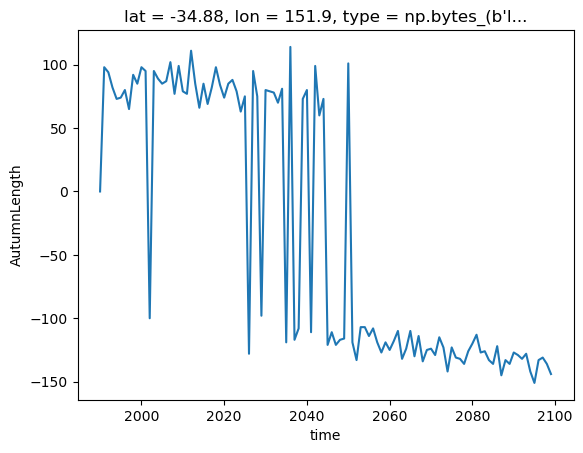

In [24]:
# autumn length for Sydney
sh_autumn.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot()

In [186]:
# (sh.loc[dict(lat=-90, lon=-180, time='1962')].WinterStart.values - (sh.loc[dict(lat=-90, lon=-180, time='1961')].SummerEnd - 183).values)[0]

In [185]:
# sh['AutumnLength'].loc[dict(lat=-90, lon=-180, time='1962')] = (sh.loc[dict(lat=-90, lon=-180, time='1962')].WinterStart.values - (sh.loc[dict(lat=-90, lon=-180, time='1961')].SummerEnd - 183).values)[0]

# #sh['AutumnLength'].loc[dict(lat=-90, lon=-180, time='1962')] = sh.loc[dict(lat=-90, lon=-180, time='1962')].WinterStart.values - (sh.loc[dict(lat=-90, lon=-180, time='1962')].SummerEnd - 183).values

# sh.loc[dict(lat=-90, lon=-180, time='1962')]['AutumnLength']

#### OK, have SH Autumns - but there are many zero length winters which is causing havoc

### NH Autumns are easy

In [25]:
# NH autumns are easy
# autumnstart = ds_tmp.sel(time=str(year)).SummerEnd.values
# autumnend = ds_tmp.sel(time=str(year)).WinterStart.values+183
# autumnlength = int(autumnend[0] - autumnstart[0])
nh['AutumnLength'] = (nh.WinterStart + 183) - nh.SummerEnd
nh

<xarray.Dataset> Size: 31MB
Dimensions:       (time: 110, lat: 32, lon: 128)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
  * lat           (lat) float64 256B 1.395 4.186 6.977 ... 82.31 85.1 87.86
  * lon           (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    type          |S4 4B ...
Data variables:
    WinterStart   (time, lat, lon) float64 4MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    WinterEnd     (time, lat, lon) float64 4MB ...
    WinterLength  (time, lat, lon) float64 4MB ...
    sftlf         (time, lat, lon) float32 2MB ...
    SummerStart   (time, lat, lon) float64 4MB ...
    SummerEnd     (time, lat, lon) float64 4MB ...
    SummerLength  (time, lat, lon) float64 4MB ...
    SpringLength  (time, lat, lon) float64 4MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    AutumnLength  (time, lat, lon) float64 4MB -162.0 -152.0 ... -182.0 -182.0

### NH Springs are trickier

In [26]:
nh_spring = nh.SpringLength.copy(deep=True)
nh_spring

<xarray.DataArray 'SpringLength' (time: 110, lat: 32, lon: 128)> Size: 4MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(110, 32, 128))
Coordinates:
  * time     (time) datetime64[ns] 880B 1990-01-01 1991-01-01 ... 2099-01-01
  * lat      (lat) float64 256B 1.395 4.186 6.977 9.767 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB -180.0 -177.2 -174.4 -171.6 ... 171.6 174.4 177.2
    type     |S4 4B ...

In [ ]:
# springstart = ds_tmp.sel(time=str(year - 1)).WinterEnd.values - 183
# springend = ds_tmp.sel(time=str(year)).SummerStart.values
# springlength = int(springend[0] - springstart[0])


In [27]:
proc_yrs = np.arange(1991, 2100)
for yr in proc_yrs:
    nh_spring.loc[dict(lat=slice(0,90), lon=slice(-180,180), time=str(yr))] = nh.SummerStart.sel(time = str(yr)).values - (nh.WinterEnd.sel(time = str(yr - 1)) - 183).values

nh_spring

<xarray.DataArray 'SpringLength' (time: 110, lat: 32, lon: 128)> Size: 4MB
array([[[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[350., 344., 331., ..., 349., 360., 356.],
        [327., 325., 321., ..., 327., 326., 328.],
        [332., 329., 332., ..., 323., 327., 341.],
        ...,
        [ 64.,  64.,  64., ...,  64.,  64.,  64.],
        [ 60.,  60.,  59., ...,  60.,  60.,  60.],
        [ 63.,  63.,  63., ...,  62.,  62.,  62.]],

       [[228., 227., 224., ..., 281., 272., 279.],
        [296., 286., 269., ..., 309., 299., 299.],
        [407., 416., 413., ..., 404., 399., 399.],
        ...,
...
        ...,
        [320., 320., 321., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.]],

       [[184., 184., 184., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.],
        ...,
        [184., 184., 184., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.]],

       [[184., 184., 184., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.],
        ...,
        [184., 184., 184., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.],
        [184., 184., 184., ..., 184., 184., 184.]]], shape=(110, 32, 128))
Coordinates:
  * time     (time) datetime64[ns] 880B 1990-01-01 1991-01-01 ... 2099-01-01
  * lat      (lat) float64 256B 1.395 4.186 6.977 9.767 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB -180.0 -177.2 -174.4 -171.6 ... 171.6 174.4 177.2
    type     |S4 4B ...

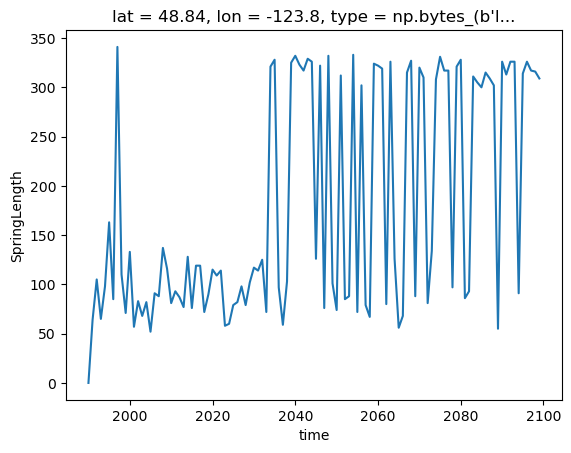

In [28]:
# spring length for Vancouver
van_lat = 49.246
van_lon = -123.116
nh_spring.sel(lat=van_lat, lon=van_lon, method='nearest').plot()

## OK, things to note: since we sometimes have winter start/end = 0 due to NO winter from Fourier fit
- negative lengths for autumns should be replaced by zero
- large values for NH springs should be replaced by zero (e.g. see Vancouver 2040? above)

In [29]:
ds_canesm5_seasons

<xarray.Dataset> Size: 61MB
Dimensions:       (time: 110, lat: 64, lon: 128)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
  * lat           (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon           (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    type          |S4 4B ...
Data variables:
    WinterStart   (time, lat, lon) float64 7MB ...
    WinterEnd     (time, lat, lon) float64 7MB ...
    WinterLength  (time, lat, lon) float64 7MB ...
    sftlf         (time, lat, lon) float32 4MB ...
    SummerStart   (time, lat, lon) float64 7MB ...
    SummerEnd     (time, lat, lon) float64 7MB ...
    SummerLength  (time, lat, lon) float64 7MB ...
    SpringLength  (time, lat, lon) float64 7MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    AutumnLength  (time, lat, lon) float64 7MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

### Now merge all the data back together to write it out

In [30]:
nh['SpringLength'] = nh_spring

# check van
nh.sel(lat=van_lat, lon=van_lon, method='nearest')

<xarray.Dataset> Size: 8kB
Dimensions:       (time: 110)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
    lat           float64 8B 48.84
    lon           float64 8B -123.8
    type          |S4 4B ...
Data variables:
    WinterStart   (time) float64 880B 155.0 130.0 221.0 149.0 ... 0.0 0.0 0.0
    WinterEnd     (time) float64 880B ...
    WinterLength  (time) float64 880B ...
    sftlf         (time) float32 440B ...
    SummerStart   (time) float64 880B ...
    SummerEnd     (time) float64 880B ...
    SummerLength  (time) float64 880B ...
    SpringLength  (time) float64 880B 0.0 64.0 105.0 65.0 ... 317.0 316.0 309.0
    AutumnLength  (time) float64 880B 89.0 68.0 160.0 ... -99.0 -95.0 -102.0

In [31]:
syd_lat = -33 - 52/60 - 4/3600
syd_lon = 151.25

sh['AutumnLength'] = sh_autumn

# check Sydney
sh.sel(lat=syd_lat, lon=syd_lon, method='nearest')

<xarray.Dataset> Size: 8kB
Dimensions:       (time: 110)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
    lat           float64 8B -34.88
    lon           float64 8B 151.9
    type          |S4 4B ...
Data variables:
    WinterStart   (time) float64 880B ...
    WinterEnd     (time) float64 880B ...
    WinterLength  (time) float64 880B ...
    sftlf         (time) float32 440B ...
    SummerStart   (time) float64 880B 163.0 166.0 189.0 ... 116.0 129.0 112.0
    SummerEnd     (time) float64 880B ...
    SummerLength  (time) float64 880B ...
    SpringLength  (time) float64 880B 105.0 95.0 144.0 ... 299.0 312.0 295.0
    AutumnLength  (time) float64 880B 0.0 98.0 94.0 ... -131.0 -136.0 -144.0

In [32]:
combined = nh.merge(sh)
combined

<xarray.Dataset> Size: 61MB
Dimensions:       (lat: 64, lon: 128, time: 110)
Coordinates:
  * lat           (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon           (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
    type          |S4 4B b'land'
Data variables:
    WinterStart   (time, lat, lon) float64 7MB 238.0 237.0 236.0 ... 0.0 0.0 0.0
    WinterEnd     (time, lat, lon) float64 7MB 259.0 260.0 260.0 ... 0.0 0.0 0.0
    WinterLength  (time, lat, lon) float64 7MB 22.0 24.0 25.0 ... 0.0 0.0 0.0
    sftlf         (time, lat, lon) float32 4MB 100.0 100.0 100.0 ... 0.0 0.0 0.0
    SummerStart   (time, lat, lon) float64 7MB 140.0 140.0 140.0 ... 1.0 1.0 1.0
    SummerEnd     (time, lat, lon) float64 7MB 227.0 228.0 228.0 ... 365.0 365.0
    SummerLength  (time, lat, lon) float64 7MB 88.0 89.0 89.0 ... 365.0 365.0
    SpringLength  (time, lat, lon) float64 7MB 64.0 63.0 63.0 ... 184.0 184.0
    AutumnLength  (time, lat, lon) float64 7MB 0.0 0.0 0.0 ... -182.0 -182.0

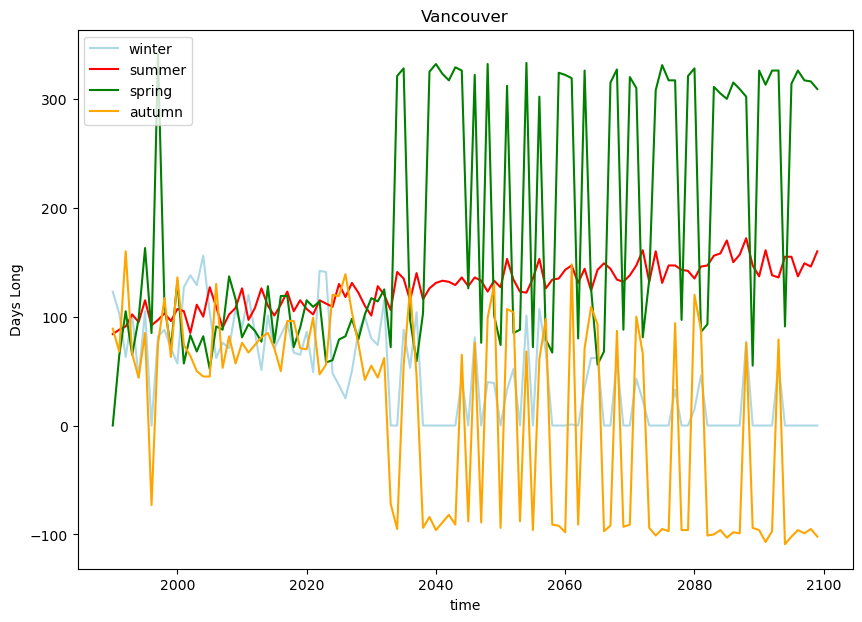

In [33]:
# plot Van seasons
plt.figure(figsize=(10,7))
combined.WinterLength.sel(lat=van_lat, lon=van_lon, method='nearest').plot(color="lightblue", label="winter")
combined.SummerLength.sel(lat=van_lat, lon=van_lon, method='nearest').plot(color="red", label="summer")
combined.SpringLength.sel(lat=van_lat, lon=van_lon, method='nearest').plot(color="green", label="spring")
combined.AutumnLength.sel(lat=van_lat, lon=van_lon, method='nearest').plot(color="orange", label="autumn")
plt.ylabel("Days Long")
plt.title("Vancouver")
plt.legend()
plt.show()

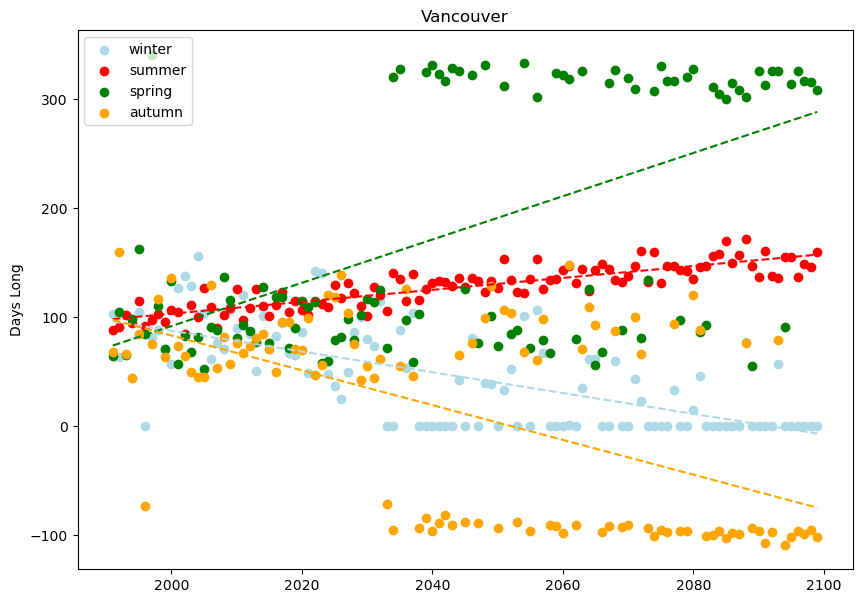

In [34]:
# plot Vancouver seasons as scatter plot with linear fits
van_data = combined.sel(lat=van_lat, lon=van_lon, method='nearest')
van_data = van_data.sel(time=slice('1991','2099'))

plt.figure(figsize=(10,7))
x = van_data.time.dt.year.values
y = van_data.WinterLength.values
plt.scatter(x=x, y=y, color="lightblue", label="winter")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="lightblue", linestyle="dashed")

y = van_data.SummerLength.values
plt.scatter(x=x, y=y, color="red", label="summer")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="red", linestyle="dashed")

y = van_data.SpringLength.values
plt.scatter(x=x, y=y, color="green", label="spring")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="green", linestyle="dashed")

y = van_data.AutumnLength.values
plt.scatter(x=x, y=y, color="orange", label="autumn")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="orange", linestyle="dashed")
plt.ylabel("Days Long")
plt.title("Vancouver")
plt.legend()
plt.show()

In [244]:
combined.sel(lat=syd_lat, lon=syd_lon, method='nearest')

<xarray.Dataset> Size: 5kB
Dimensions:       (time: 65)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
    lat           float64 8B -33.75
    lon           float64 8B 151.2
Data variables:
    WinterStart   (time) float64 520B 154.0 158.0 157.0 ... 152.0 155.0 161.0
    WinterEnd     (time) float64 520B 248.0 244.0 248.0 ... 208.0 211.0 224.0
    WinterLength  (time) float64 520B 95.0 87.0 92.0 81.0 ... 57.0 57.0 64.0
    Coastal       (time) float64 520B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    SummerStart   (time) float64 520B 177.0 177.0 169.0 ... 146.0 141.0 139.0
    SummerEnd     (time) float64 520B 258.0 268.0 266.0 ... 275.0 292.0 276.0
    SummerLength  (time) float64 520B 82.0 92.0 98.0 54.0 ... 130.0 152.0 138.0
    SpringLength  (time) float64 520B 112.0 116.0 104.0 ... 121.0 113.0 98.0
    AutumnLength  (time) float64 520B 0.0 83.0 72.0 71.0 ... 71.0 62.0 63.0 52.0

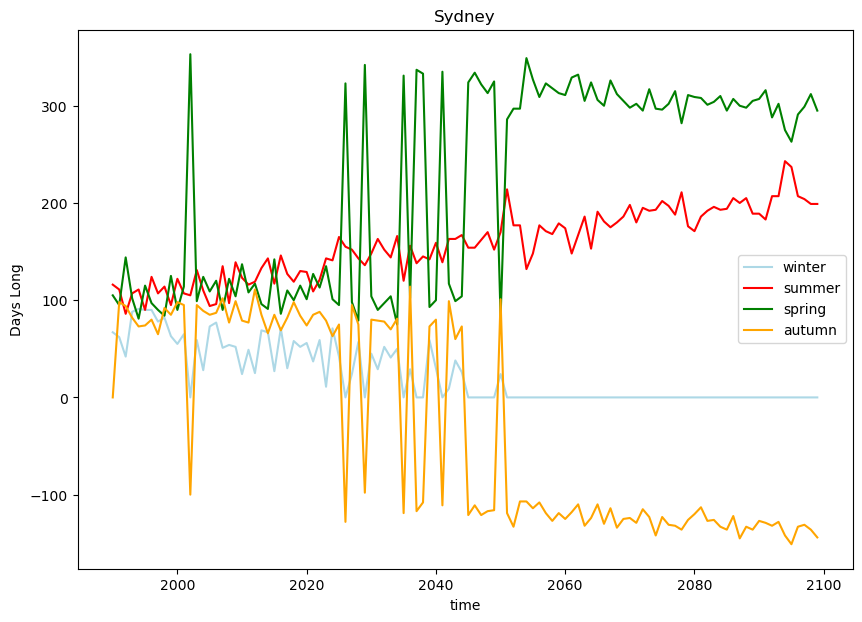

In [35]:
# plot Sydney seasons but scatter plot
plt.figure(figsize=(10,7))
combined.WinterLength.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot(color="lightblue", label="winter")
combined.SummerLength.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot(color="red", label="summer")
combined.SpringLength.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot(color="green", label="spring")
combined.AutumnLength.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot(color="orange", label="autumn")
plt.ylabel("Days Long")
plt.title("Sydney")
plt.legend()
plt.show()

### Write it out

In [36]:
# write out complete dataset with LSM and Coastal flags
output_path = '../../../../Data/CMIP6/CanESM5/Seasons-SSP2-45/1990-2100_ALL_season_stats.nc'
combined.to_netcdf(output_path)

# **** Start Here Now

In [37]:
# read it back in and can re-use ds_seasons name
input_path = '../../../../Data/CMIP6/CanESM5/Seasons-SSP2-45/1990-2100_ALL_season_stats.nc'
ds_canesm5_seasons = xr.open_dataset(input_path)
ds_canesm5_seasons

<xarray.Dataset> Size: 61MB
Dimensions:       (time: 110, lat: 64, lon: 128)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
  * lat           (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon           (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    type          |S4 4B ...
Data variables:
    WinterStart   (time, lat, lon) float64 7MB ...
    WinterEnd     (time, lat, lon) float64 7MB ...
    WinterLength  (time, lat, lon) float64 7MB ...
    sftlf         (time, lat, lon) float32 4MB ...
    SummerStart   (time, lat, lon) float64 7MB ...
    SummerEnd     (time, lat, lon) float64 7MB ...
    SummerLength  (time, lat, lon) float64 7MB ...
    SpringLength  (time, lat, lon) float64 7MB ...
    AutumnLength  (time, lat, lon) float64 7MB ...

## Weighted mean for NH and SH, and also make func for any grid square

In [38]:
# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_canesm5_seasons.lat))
weights.name = "weights"

### Land Only for now

In [40]:
%%time

# takes 9 sec

# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

# datasets of weighted averages for the midlatitudes
nh_land_full = ds_canesm5_seasons.where((ds_canesm5_seasons.sftlf > 50) & 
                             ((ds_canesm5_seasons.lat >= nh_min) & (ds_canesm5_seasons.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_full = ds_canesm5_seasons.where((ds_canesm5_seasons.sftlf > 50) &  
                             ((ds_canesm5_seasons.lat >= sh_max) & (ds_canesm5_seasons.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])


CPU times: user 96 ms, sys: 58.7 ms, total: 155 ms
Wall time: 152 ms


In [41]:
nh_land_full

<xarray.Dataset> Size: 9kB
Dimensions:       (time: 110)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
    type          |S4 4B b'land'
Data variables:
    WinterStart   (time) float64 880B 156.7 153.1 150.3 ... 76.27 64.17 58.57
    WinterEnd     (time) float64 880B 242.2 252.2 253.2 ... 98.83 81.55 70.41
    WinterLength  (time) float64 880B 86.42 100.1 103.8 ... 23.02 17.74 12.16
    sftlf         (time) float64 880B 95.69 95.69 95.69 ... 95.69 95.69 95.69
    SummerStart   (time) float64 880B 150.4 152.2 155.7 ... 131.6 128.8 133.0
    SummerEnd     (time) float64 880B 247.8 249.9 247.4 ... 275.5 275.7 275.7
    SummerLength  (time) float64 880B 98.42 98.67 92.76 ... 144.9 147.9 143.7
    SpringLength  (time) float64 880B 0.0 93.08 86.49 ... 246.4 213.0 234.5
    AutumnLength  (time) float64 880B 91.91 86.16 85.91 ... -16.25 -28.51 -34.13

In [42]:
# create data for bar plot
# get fraction of 365 days that are each season each year
x = ds_canesm5_seasons.time.dt.year.values
nh_AL = nh_land_full.AutumnLength.values#/365.0
nh_WL = nh_land_full.WinterLength.values#/365.0
nh_SpL = nh_land_full.SpringLength.values#/365.0
nh_SL = nh_land_full.SummerLength.values#/365.0
nh_sums = nh_AL + nh_WL + nh_SpL + nh_SL
print(nh_sums)

# normalize so each year has same total length and each season is a fraction of that year
nh_ALn = nh_AL/nh_sums
nh_WLn = nh_WL/nh_sums
nh_SpLn = nh_SpL/nh_sums
nh_SLn = nh_SL/nh_sums


# same for SH
sh_AL = sh_land_full.AutumnLength.values#/365.0
sh_WL = sh_land_full.WinterLength.values#/365.0
sh_SpL = sh_land_full.SpringLength.values#/365.0
sh_SL = sh_land_full.SummerLength.values#/365.0
sh_sums = sh_AL + sh_WL + sh_SpL + sh_SL

# normalize so each year has same total length and each season is a fraction of that year
sh_ALn = sh_AL/sh_sums
sh_WLn = sh_WL/sh_sums
sh_SpLn = sh_SpL/sh_sums
sh_SLn = sh_SL/sh_sums

[276.75473368 378.03405958 368.97323504 356.46188272 362.6792309
 370.91475017 375.76848462 370.95752417 365.69128471 359.17715894
 350.75676246 384.4748332  363.28851835 376.72459511 366.8255323
 363.5300771  373.74998362 358.37541074 374.13277877 360.8142952
 373.06350458 361.93644596 373.98142644 370.18418353 356.03009955
 371.65412663 376.47799134 360.60809059 378.4326527  352.45249769
 360.82682688 374.63058663 373.4591446  338.03252105 377.8802312
 344.98546245 401.08785625 357.26167786 384.12063504 368.75077128
 348.95837968 380.58425837 344.87911021 347.19990711 376.7975003
 393.61185412 352.10113902 395.48191926 344.19441385 357.54772601
 363.90152114 312.49804824 437.90092497 345.15530075 356.57738932
 372.3995367  382.67268301 366.66796173 306.62469246 423.37301742
 375.77579226 359.72479682 343.16716709 380.20493569 380.56932496
 324.988724   342.01902903 405.55052149 358.35284604 340.70480199
 428.09163205 355.3806539  340.04998303 406.86956971 361.66909361
 353.09425513 3

### Calculate lengths as anomalies from 1991-2020 average season lengths

In [44]:
nh_seas_mean_base = nh_land_full.sel(time=slice('1991','2020')).mean()
nh_seas_mean_base

<xarray.Dataset> Size: 76B
Dimensions:       ()
Coordinates:
    type          |S4 4B b'land'
Data variables:
    WinterStart   float64 8B 154.3
    WinterEnd     float64 8B 237.6
    WinterLength  float64 8B 84.26
    sftlf         float64 8B 95.69
    SummerStart   float64 8B 148.8
    SummerEnd     float64 8B 254.6
    SummerLength  float64 8B 106.7
    SpringLength  float64 8B 93.5
    AutumnLength  float64 8B 82.74

In [45]:
nh_land_anom = nh_land_full - nh_seas_mean_base
nh_land_anom = nh_land_anom.drop_vars(['WinterStart','WinterEnd','SummerStart','SummerEnd','sftlf'])
nh_land_anom

<xarray.Dataset> Size: 4kB
Dimensions:       (time: 110)
Coordinates:
  * time          (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
    type          |S4 4B b'land'
Data variables:
    WinterLength  (time) float64 880B 2.161 15.86 19.56 ... -61.24 -66.52 -72.11
    SummerLength  (time) float64 880B -8.314 -8.061 -13.98 ... 38.21 41.15 36.96
    SpringLength  (time) float64 880B -93.5 -0.4239 -7.012 ... 152.9 119.5 141.0
    AutumnLength  (time) float64 880B 9.174 3.427 3.174 ... -98.98 -111.3 -116.9

#### 5 yr averages

In [59]:
nh_land_anom_5Y = nh_land_anom.resample(time='5YE').mean(dim='time')
nh_land_anom_5Y

<xarray.Dataset> Size: 924B
Dimensions:       (time: 23)
Coordinates:
  * time          (time) datetime64[ns] 184B 1990-12-31 ... 2100-12-31
    type          |S4 4B b'land'
Data variables:
    WinterLength  (time) float64 184B 2.161 11.97 2.943 ... -64.41 -62.77 -68.12
    SummerLength  (time) float64 184B -8.314 -9.236 -4.228 ... 38.28 41.33 39.09
    SpringLength  (time) float64 184B -93.5 -2.653 -3.914 ... 116.6 111.3 128.3
    AutumnLength  (time) float64 184B 9.174 0.1031 2.437 ... -87.26 -111.4

Text(0, 0.5, 'Length vs 1991-2020 Mean [Days]')

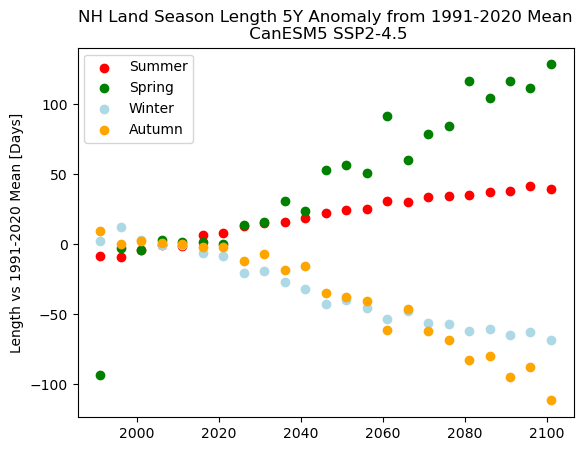

In [69]:
# sel(time=slice('1990','2025')).
plt.figure()
plt.scatter(nh_land_anom_5Y.time, nh_land_anom_5Y.SummerLength,label="Summer", color="red")
plt.scatter(nh_land_anom_5Y.time, nh_land_anom_5Y.SpringLength, label="Spring", color="green")
plt.scatter(nh_land_anom_5Y.time, nh_land_anom_5Y.WinterLength,label="Winter", color="lightblue")
plt.scatter(nh_land_anom_5Y.time, nh_land_anom_5Y.AutumnLength,label="Autumn", color="orange")
plt.legend()
#plt.ylim(-30,30)
plt.title("NH Land Season Length 5Y Anomaly from 1991-2020 Mean\n CanESM5 SSP2-4.5")
plt.ylabel("Length vs 1991-2020 Mean [Days]")
#plt.xlim(dt(1989,1,1),dt(2025,12,31))


### NH Land Stacked Bars

Update - order needs to be Spring - Summer - Autumn - Winter starting with 1962 (first year with full set, and winter starts in 1962 but spans into 1963)

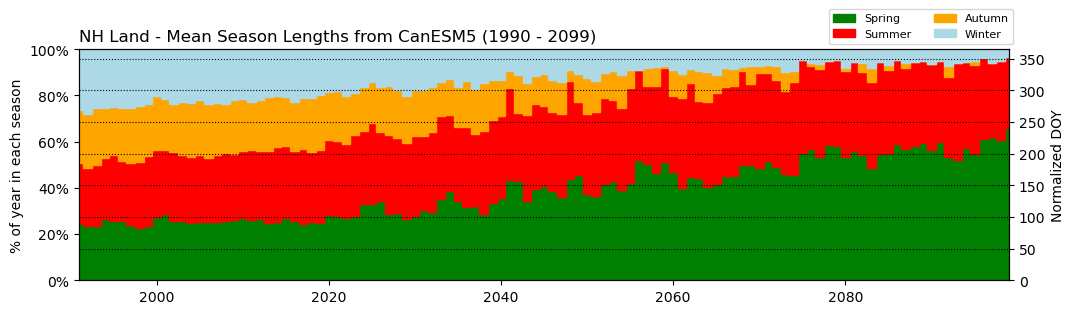

In [72]:
fs=8
barWidth = 1

fig = plt.figure(figsize=(12,3))

ax = fig.add_subplot()

# Spring
plt.bar(x, nh_SpLn, color='green', edgecolor='green', width=barWidth, label="Spring")
# Summer
plt.bar(x, nh_SLn, bottom = nh_SpLn, color='red', edgecolor='red', width=barWidth, label="Summer")
# Autumn bars
plt.bar(x, nh_ALn, bottom = nh_SpLn + nh_SLn, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
# Winter, on top of the first ones - in NH spans two calendar years
plt.bar(x, nh_WLn, bottom = nh_SpLn + nh_SLn + nh_ALn, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")


 
# labels, etc
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.ylabel("% of year in each season")

# Put a legend to the right of the current axis
#get handles and labels https://www.statology.org/matplotlib-legend-order/
handles, labels = plt.gca().get_legend_handles_labels()

#specify order of items in legend
order = [0,1,2,3]

#add legend to plot
# plt.legend()
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=fs, bbox_to_anchor=(0.8, 1), loc="lower left", ncol=2)#'upper left', bbox_to_anchor=(1, 1))

ax.set_ylim(0,1)

# add right labels
ax2 = ax.twinx()

ax2.set_ylim(0,365)
ax2.set_ylabel("Normalized DOY")

# adjust x axis so legend is visible
plt.xlim(1991,2099)
plt.grid(axis='both', which = 'both', linestyle=':', color="black")


plt.title("NH Land - Mean Season Lengths from CanESM5 (1990 - 2099)", loc='left')

plt.show()

### SH Land Stacked Bars

Update - order needs to be Autumn - Winter - Spring - Summer starting with 1962 (first year with full set, and summer starts in 1962 but spans into 1963)

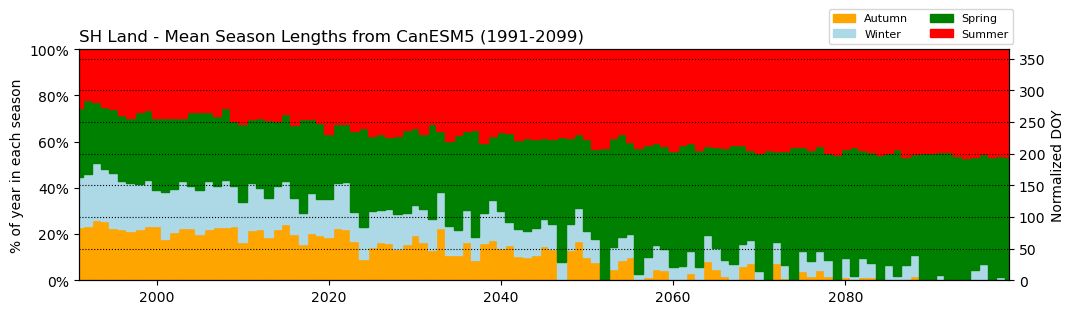

In [73]:
fs=8
barWidth = 1

fig = plt.figure(figsize=(12,3))

ax = fig.add_subplot()

# Autumn bars
plt.bar(x, sh_ALn, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
# Winter, on top of the first ones
plt.bar(x, sh_WLn, bottom=sh_ALn, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")
# Spring
plt.bar(x, sh_SpLn, bottom= sh_ALn + sh_WLn, color='green', edgecolor='green', width=barWidth, label="Spring")
# Summer
plt.bar(x, sh_SLn, bottom= sh_ALn + sh_WLn + sh_SpLn, color='red', edgecolor='red', width=barWidth, label="Summer")
 
# labels, etc
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.ylabel("% of year in each season")

# Put a legend to the right of the current axis
#get handles and labels https://www.statology.org/matplotlib-legend-order/
handles, labels = plt.gca().get_legend_handles_labels()

#specify order of items in legend
order = [0,1,2,3]

#add legend to plot
# plt.legend()
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=fs, bbox_to_anchor=(0.8, 1), loc="lower left", ncol=2)#'upper left', bbox_to_anchor=(1, 1))

ax.set_ylim(0,1)

# add right labels
ax2 = ax.twinx()

ax2.set_ylim(0,365)
ax2.set_ylabel("Normalized DOY")

# adjust x axis so legend is visible
plt.xlim(1991,2099)
plt.grid(axis='both', which = 'both', linestyle=':', color="black")


plt.title("SH Land - Mean Season Lengths from CanESM5 (1991-2099)", loc='left')

plt.show()

### Function for any lat/lon

In [79]:
def MakeSeasonsPlot(input_lat, input_lon):
    '''

    Function that produces the length of each season over 1961-2025 (ds_seasons is already loaded) as a stacked bar plot.
    In in SH, starts with Autumn in 1962 (summer spans two calendar years), and in NH starts with Spring in 1962 (winter spans two years).

    Args:
        input_lat, input_lon: the lat and lon of the cell of interest, note func uses method='nearest'
        to get the nearest grid square from ERA5 at 0.25 deg resolution. Lat [-90,90], Lon [-180, 180]
        
    Returns:
        nothing
        
    Example:
        # for Vancouver, BC
        MakeSeasonsPlot(49.246, -123.116)

    '''

    if ((input_lat > -23.5) & (input_lat < 23.5)):
        print("Grid location not in midlatitudes! Results may be unexpected!")

    # filter data to nearest location of interested 
    ds = ds_canesm5_seasons.sel(lat=input_lat, lon=input_lon, method='nearest')
    ds = ds.sel(time=slice('1990','2100'))

    # remove years with no winter for plot
    #ds = ds.where(ds.WinterLength > 0)
    
    # create data for bar plot
    # get fraction of 365 days that are each season each year
    x = ds.time.dt.year.values
    # AL = ds.AutumnLength.values/365.0
    # WL = ds.WinterLength.values/365.0
    # SpL = ds.SpringLength.values/365.0
    # SL = ds.SummerLength.values/365.0

    AL = np.abs(ds.AutumnLength/365.0)
    WL = np.abs(ds.WinterLength/365.0)
    SpL = np.abs(ds.SpringLength/365.0)
    SL = np.abs(ds.SummerLength/365.0)
    sums = AL + WL + SpL + SL
    
    # what if WL == 0?
    sums = xr.where((ds["WinterLength"] == 0), AL + SpL + SL, AL + WL + SpL + SL)
    
    # normalize so each year has same total length and each season is a fraction of that year
    ALn = AL/sums
    WLn = WL/sums
    SpLn = SpL/sums
    SLn = SL/sums

    # plotting
    fs=8
    barWidth = 1
    
    fig = plt.figure(figsize=(12,3))
    ax = fig.add_subplot()

    if (input_lat <= -23.5):
        # Autumn bars
        plt.bar(x, ALn, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones
        plt.bar(x, WLn, bottom=ALn, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")
        # Spring
        plt.bar(x, SpLn, bottom= ALn + WLn, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn, bottom= ALn + WLn + SpLn, color='red', edgecolor='red', width=barWidth, label="Summer")

    else:
        # Spring
        plt.bar(x, SpLn, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn, bottom = SpLn, color='red', edgecolor='red', width=barWidth, label="Summer")
        # Autumn bars
        plt.bar(x, ALn, bottom = SpLn + SLn, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones - in NH spans two calendar years
        plt.bar(x, WLn, bottom = SpLn + SLn + ALn, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")

    # labels, etc
    plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
    plt.ylabel("% of year in each season")
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    
    # Put a legend to the right of the current axis
    handles, labels = plt.gca().get_legend_handles_labels()
        
    #specify order of items in legend
    order = [0,1,2,3]
    
    #add legend to plot
    ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=fs, bbox_to_anchor=(0.8, 1), loc="lower left", ncol=2)#'upper left', bbox_to_anchor=(1, 1))
    
    ax.set_ylim(0,1)
    
    # add right labels
    ax2 = ax.twinx()
    
    ax2.set_ylim(0,365)
    ax2.set_ylabel("Normalized DOY")   
    # limit x to complete data regardless of hemisphere
    plt.xlim(1991,2099)
    plt.grid(axis='both', which = 'both', linestyle=':', color="black")
    
    plt.title("Seasons from CanESM5 for nearest cell to ["+str(input_lat)+", "+str(input_lon)+"]", loc='left')
    plt.show()

#### Vancouver

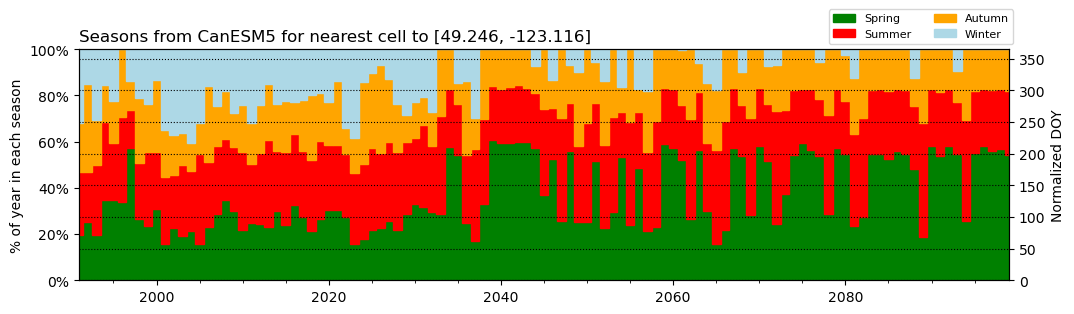

In [80]:
MakeSeasonsPlot(49.246, -123.116)

#### Minneapolis

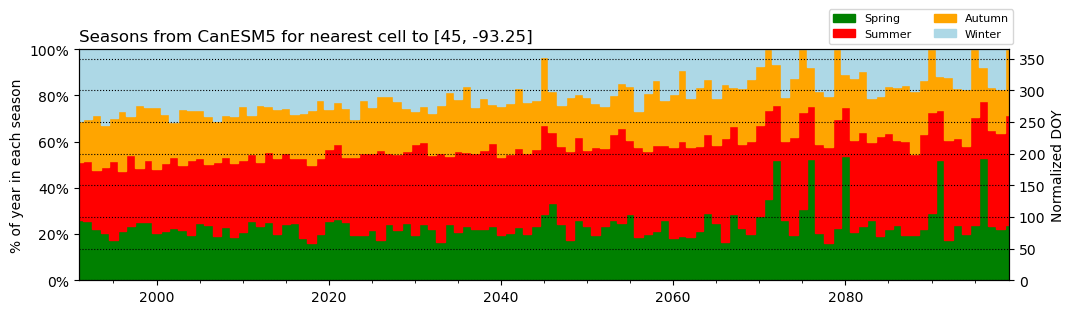

In [81]:
# Minneapolis
MakeSeasonsPlot(45, -93.25)

#### Montreal

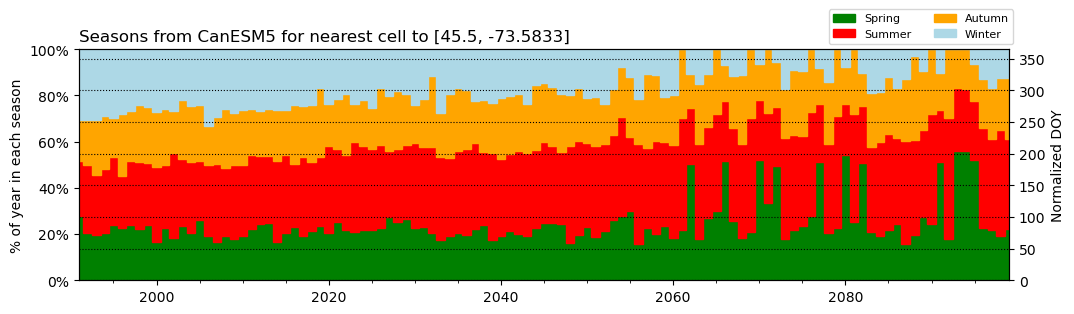

In [82]:
# Montreal 45.5	-73.5833
MakeSeasonsPlot(45.5, -73.5833)

#### Toronto

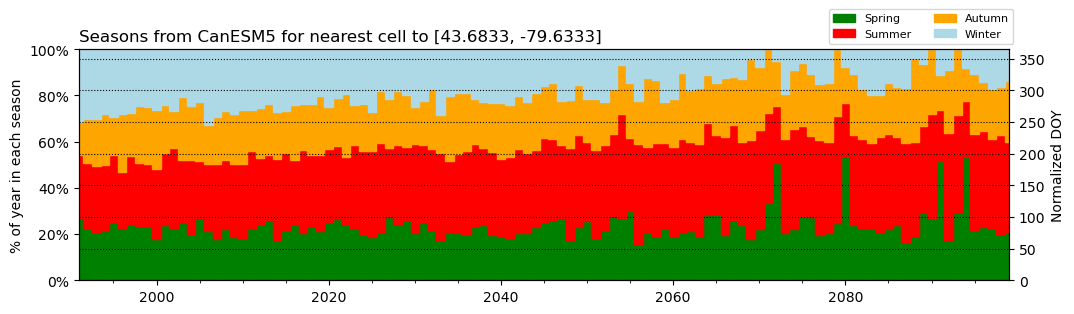

In [83]:
# Toronto 43.6833	-79.6333
MakeSeasonsPlot(43.6833,-79.6333)

#### Paris

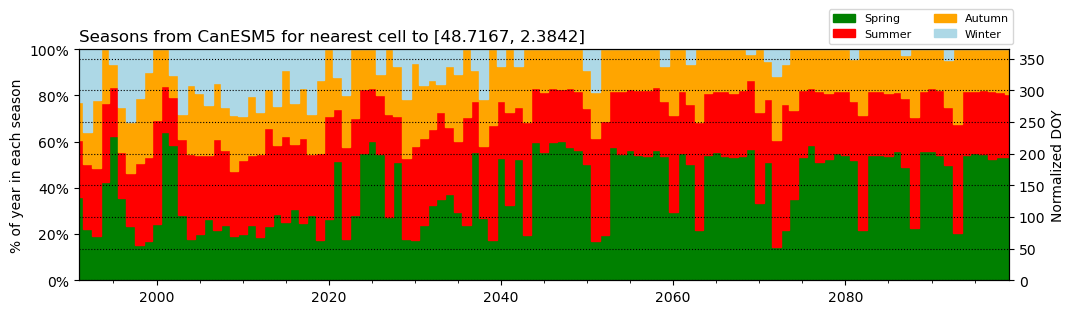

In [84]:
# Paris 48.7167	2.3842	
MakeSeasonsPlot(48.7167, 2.3842)

#### Sydney again

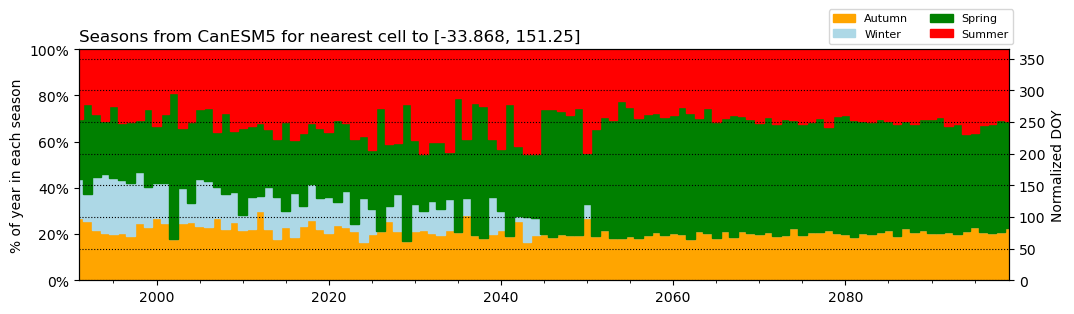

In [85]:
syd_lat = np.round(-33 - 52/60 - 4/3600, 3)
syd_lon = 151.25
MakeSeasonsPlot(syd_lat, syd_lon)

Grid location not in midlatitudes! Results may be unexpected!


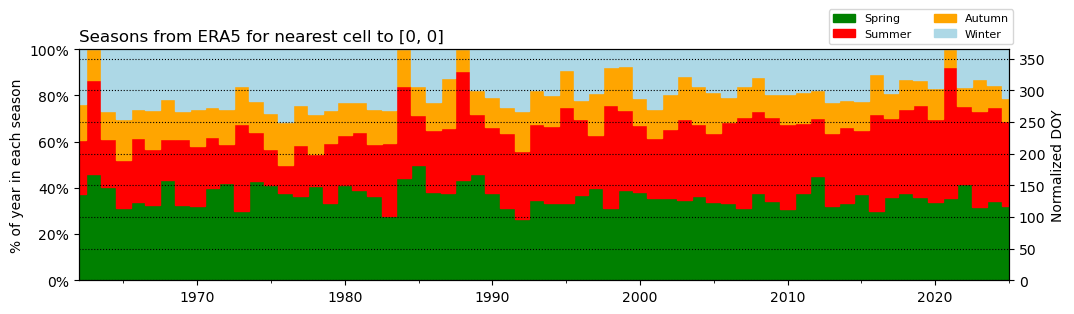

In [217]:
MakeSeasonsPlot(0,0)

#### Madrid

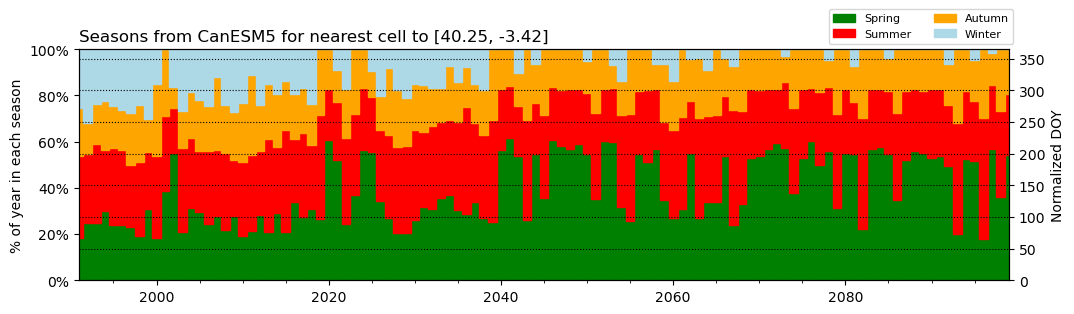

In [86]:
# Madrid 40.25, -3.42
MakeSeasonsPlot(40.25, -3.42)

### Zonal Season Length Plots

In [89]:
def MakeZonalSeasonsPlot(min_lat, max_lat, start_yr):
    '''

    Function that produces the mean length of each season over 1961-2025 (ds_seasons is already loaded) as a stacked bar plot.
    In in SH, starts with Autumn in 1962 (summer spans two calendar years), and in NH starts with Spring in 1962 (winter spans two years).
    The mean seasons are latitude weighted to those within the span of latitudes from min_lat to max_lat across all longitudes.

    The plots are produced and presented for land and ocean separately.

    Args:
        min_lat, max_lat: the lat range of interest
        start_yr: the earliest year to use (1962 is minimum), end is always 2025
        
    Returns:
        nothing
        
    Example:
        MakeZonalSeasonsPlot(20, 40, 1990)

    '''

    # filter data to complete years only
    ds = ds_canesm5_seasons.sel(time=slice(str(start_yr),'2099'))
    
    # determine zonal means as weighted averages across all longitudes
    # land
    zone_land_full = ds.sel(lat=slice(min_lat, max_lat)).where((ds.sftlf > 50)).weighted(weights).mean(dim=['lat','lon'])
    # ocean
    zone_ocean_full = ds.sel(lat=slice(min_lat, max_lat)).where((ds.sftlf <= 50)).weighted(weights).mean(dim=['lat','lon'])

    # create data for bar plot
    # get fraction of 365 days that are each season each year
    x = ds.time.dt.year.values

    ### Land
    AL_land = np.abs(zone_land_full.AutumnLength/365.0)
    WL_land = np.abs(zone_land_full.WinterLength/365.0)
    SpL_land = np.abs(zone_land_full.SpringLength/365.0)
    SL_land = np.abs(zone_land_full.SummerLength/365.0)
    sums_land = AL_land + WL_land + SpL_land + SL_land
    
    # normalize so each year has same total length and each season is a fraction of that year
    ALn_land = AL_land/sums_land
    WLn_land = WL_land/sums_land
    SpLn_land = SpL_land/sums_land
    SLn_land = SL_land/sums_land

    ### Ocean
    AL_ocean = np.abs(zone_ocean_full.AutumnLength/365.0)
    WL_ocean = np.abs(zone_ocean_full.WinterLength/365.0)
    SpL_ocean = np.abs(zone_ocean_full.SpringLength/365.0)
    SL_ocean = np.abs(zone_ocean_full.SummerLength/365.0)
    sums_ocean = AL_ocean + WL_ocean + SpL_ocean + SL_ocean
    
    # normalize so each year has same total length and each season is a fraction of that year
    ALn_ocean = AL_ocean/sums_ocean
    WLn_ocean = WL_ocean/sums_ocean
    SpLn_ocean = SpL_ocean/sums_ocean
    SLn_ocean = SL_ocean/sums_ocean
    
    # plotting
    fs=8
    barWidth = 1
    
    fig = plt.figure(figsize=(15,3), layout='constrained')
    ax = fig.add_subplot(1,2,1)

    ### LAND
    
    if (max_lat <= 0):
        # SH ordering
        # Autumn bars
        plt.bar(x, ALn_land, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones
        plt.bar(x, WLn_land, bottom=ALn_land, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")
        # Spring
        plt.bar(x, SpLn_land, bottom= ALn_land + WLn_land, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn_land, bottom= ALn_land + WLn_land + SpLn_land, color='red', edgecolor='red', width=barWidth, label="Summer")

    else:
        # NH ordering
        # Spring
        plt.bar(x, SpLn_land, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn_land, bottom = SpLn_land, color='red', edgecolor='red', width=barWidth, label="Summer")
        # Autumn bars
        plt.bar(x, ALn_land, bottom = SpLn_land + SLn_land, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones - in NH spans two calendar years
        plt.bar(x, WLn_land, bottom = SpLn_land + SLn_land + ALn_land, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")

    # labels, etc
    plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
    plt.ylabel("% of year in each season")
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.set_ylim(0,1)
    
    # add right labels
    ax1 = ax.twinx()
    ax1.set_ylim(0,365)
    ax1.set_ylabel("Normalized DOY")
    ax1.set_yticks(np.arange(0,365,50))
    
    # limit x to complete data regardless of hemisphere
    ax.set_xlim(start_yr,2099)
    ax.grid(axis='both', which = 'both', linestyle=':', color="black")
    ax.set_title("Land")

    ### OCEAN
    ax2 = fig.add_subplot(1,2,2, sharey=ax)
    if (max_lat <= 0):
        # SH ordering
        # Autumn bars
        plt.bar(x, ALn_ocean, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones
        plt.bar(x, WLn_ocean, bottom=ALn_ocean, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")
        # Spring
        plt.bar(x, SpLn_ocean, bottom= ALn_ocean + WLn_ocean, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn_ocean, bottom= ALn_ocean + WLn_ocean + SpLn_ocean, color='red', edgecolor='red', width=barWidth, label="Summer")

    else:
        # NH ordering
        # Spring
        plt.bar(x, SpLn_ocean, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn_ocean, bottom = SpLn_ocean, color='red', edgecolor='red', width=barWidth, label="Summer")
        # Autumn bars
        plt.bar(x, ALn_ocean, bottom = SpLn_ocean + SLn_ocean, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones - in NH spans two calendar years
        plt.bar(x, WLn_ocean, bottom = SpLn_ocean + SLn_ocean + ALn_ocean, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")

    # labels, etc
    #plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
    #plt.ylabel("% of year in each season")
    ax2.xaxis.set_minor_locator(MultipleLocator(5))
    
    # Put a legend to the right of the current axis
    handles, labels = plt.gca().get_legend_handles_labels()
        
    #specify order of items in legend
    order = [0,1,2,3]
    
    #add legend to plot
    ax2.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=fs, bbox_to_anchor=(-0.4, 0), loc="lower left", ncol=1)

    ax2.set_ylim(0,1)
    
    # add right labels
    ax3 = ax2.twinx()
    ax3.set_ylim(0,365)
    ax3.set_ylabel("Normalized DOY")
    ax3.set_yticks(np.arange(0,365,50))
    
    # limit x to complete data regardless of hemisphere
    plt.xlim(start_yr,2099)
    ax2.grid(axis='both', which = 'both', linestyle=':', color="black")
    ax2.set_title("Ocean")
    
    
    plt.suptitle(str(start_yr)+"-2099:"+" Seasons from CanESM5 SSP2-4.5 between ["+str(min_lat)+", "+str(max_lat)+"] Latitude\n")
    plt.show()

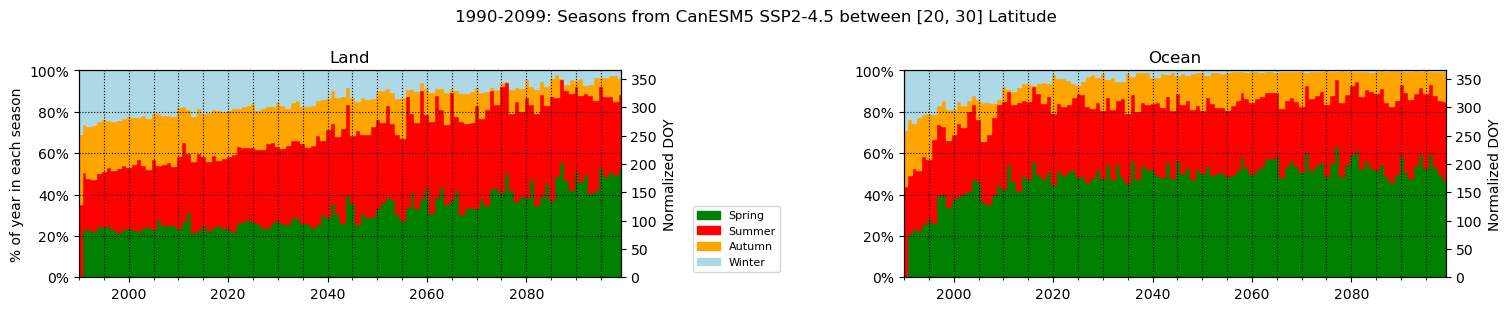

In [90]:
MakeZonalSeasonsPlot(20,30, 1990)

### NH Zonal by 10 deg

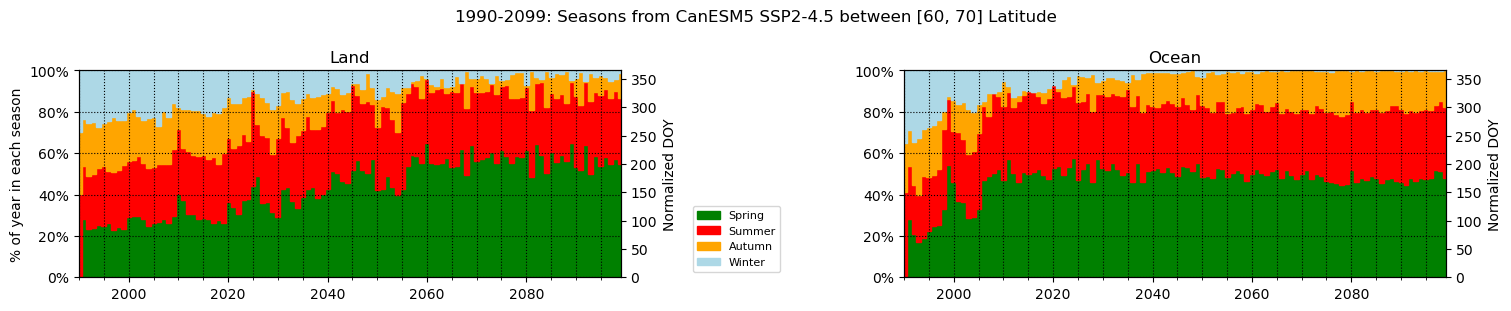

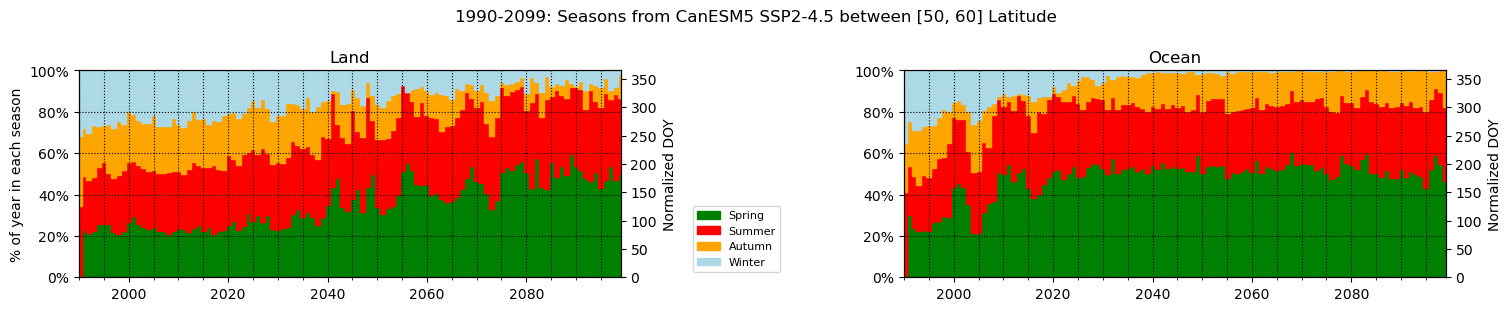

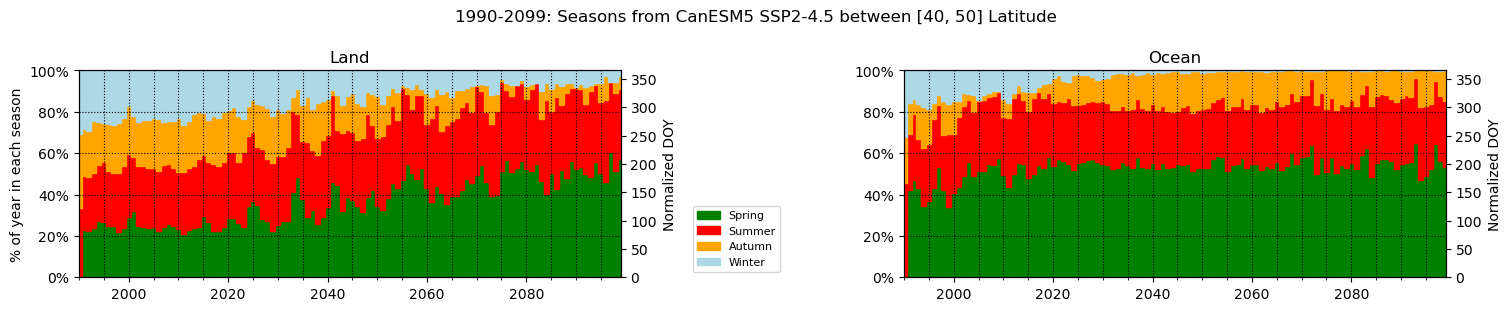

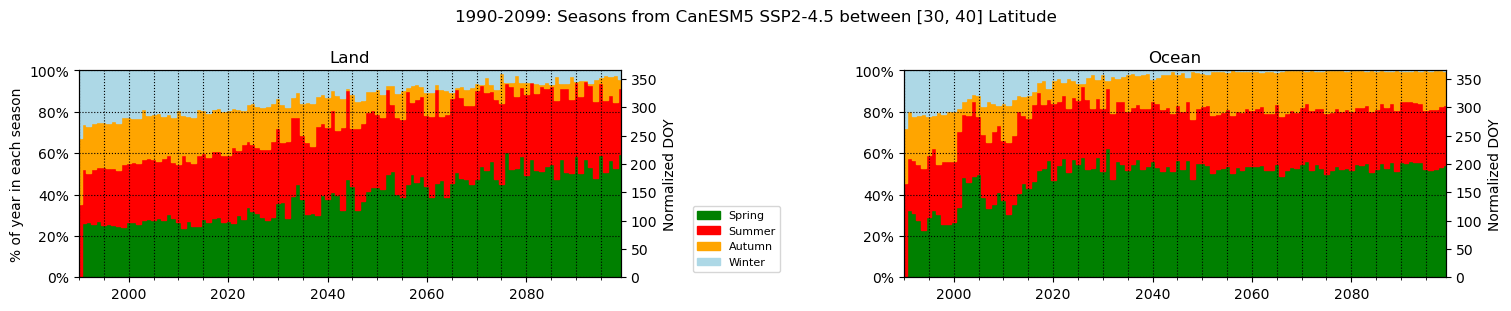

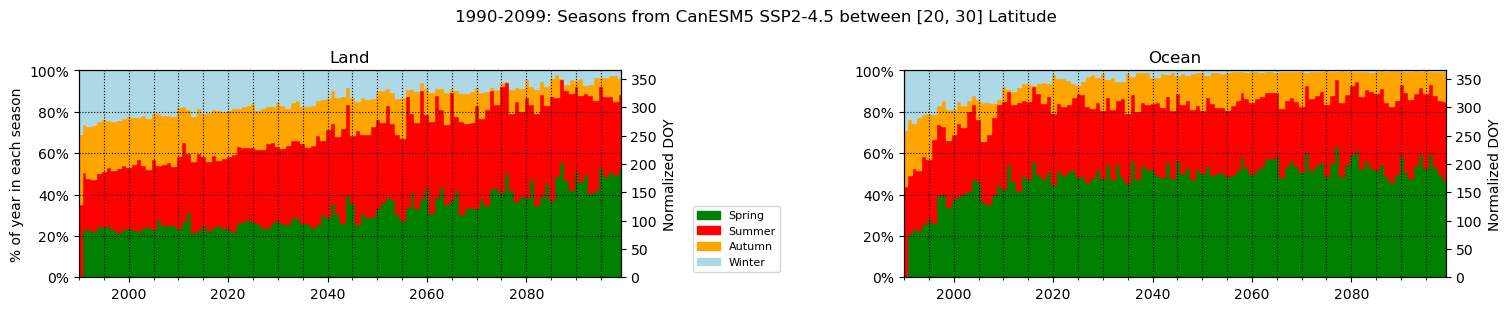

In [91]:
for i in np.arange(70,20,-10):
    MakeZonalSeasonsPlot(i-10, i, 1990)

### SH Zonal by 10 deg

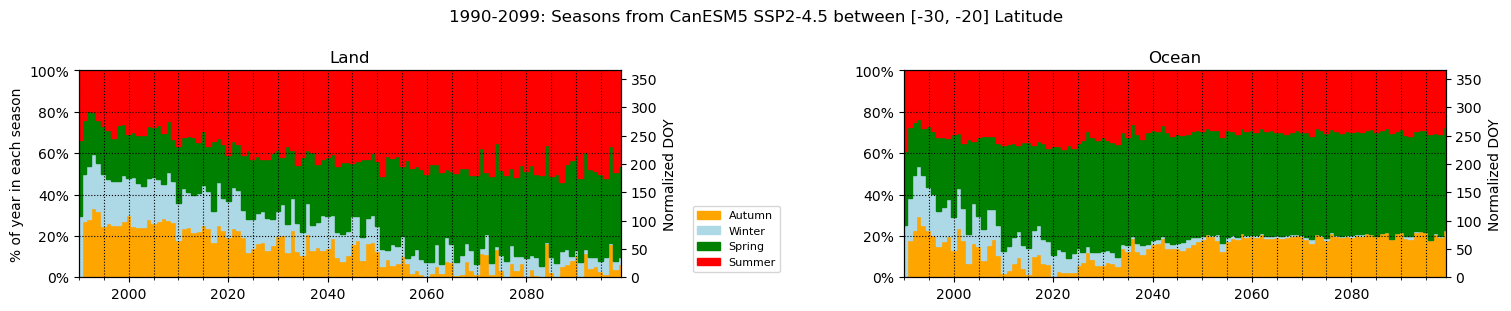

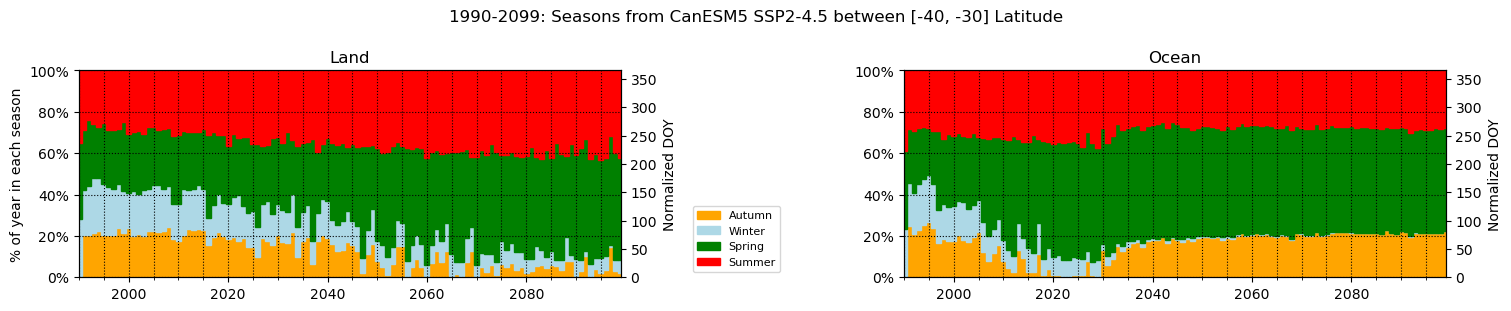

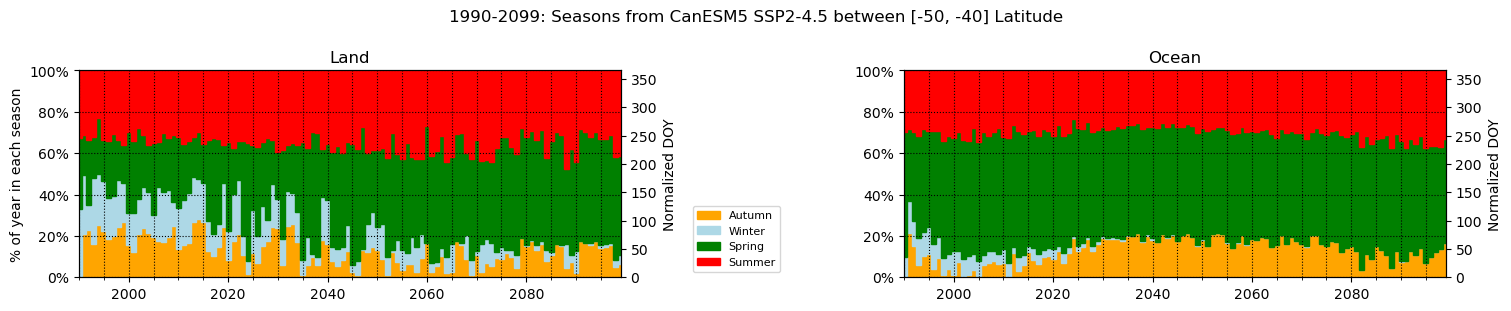

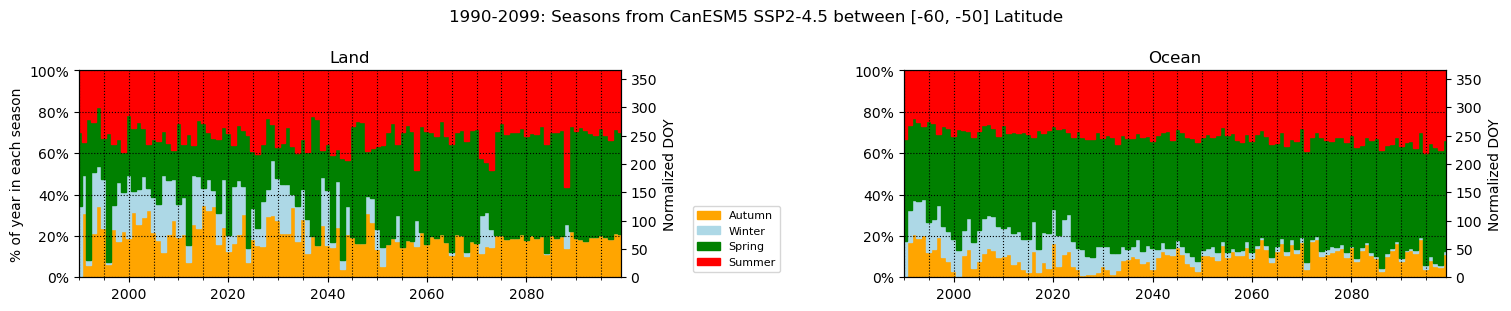

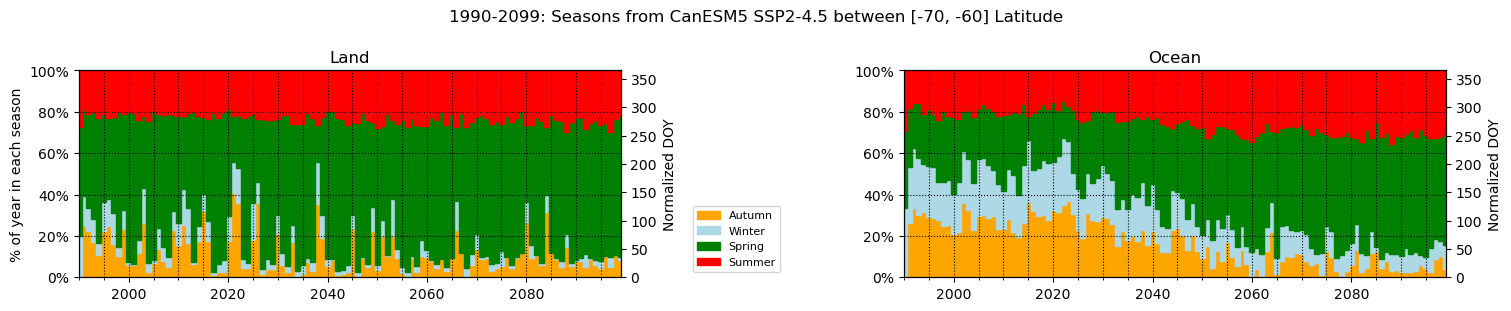

In [92]:
for i in np.arange(-20,-70,-10):
    MakeZonalSeasonsPlot(i-10, i, 1990)

## Circular Barplots of Seasons
- help from https://python-graph-gallery.com/circular-barplot-with-groups/

#### Create data frame for plot

In [93]:
# Toronto 43.6833	-79.6333
# test_lat = 43.6833
# test_lon = -79.6333

# Sydney
test_lat = np.round(-33 - 52/60 - 4/3600, 3)
test_lon = 151.25

# filter data to nearest location of interested 
ds_test = ds_canesm5_seasons.sel(lat=test_lat, lon=test_lon, method='nearest')
ds_test = ds_test.sel(time=slice('1990','2100'))

# create data for bar plot
# get fraction of 365 days that are each season each year
x = ds_test.time.dt.year.values

AL = np.abs(ds_test.AutumnLength/365.0)
WL = np.abs(ds_test.WinterLength/365.0)
SpL = np.abs(ds_test.SpringLength/365.0)
SL = np.abs(ds_test.SummerLength/365.0)
sums = AL + WL + SpL + SL

# normalize so each year has same total length and each season is a fraction of that year
ALn = AL/sums
WLn = WL/sums
SpLn = SpL/sums
SLn = SL/sums

# Build a dataset
df = pd.DataFrame({
    "year": np.concatenate((x,x,x,x)),
    "value": np.concatenate((ALn, WLn, SpLn, SLn)),
    "group": ["Autumn"] * x.size + ["Winter"] * x.size + ["Spring"] * x.size + ["Summer"] * x.size
})

# Show 3 first rows
df

,year,value,group
0,1990,0.000000,Autumn
1,1991,0.267760,Autumn
2,1992,0.256831,Autumn
3,1993,0.216359,Autumn
4,1994,0.205056,Autumn
...,...,...,...
435,2095,0.364055,Summer
436,2096,0.328051,Summer
437,2097,0.321767,Summer
438,2098,0.307573,Summer


In [95]:
# created reduced set since 1990 because that will be too many bars
# and multiply the values by 100 to get percent of normalized year
df_an = df.query("year >= 1991")
df_an['value'] = df_an['value']*100
df_an

,year,value,group
1,1991,26.775956,Autumn
2,1992,25.683060,Autumn
3,1993,21.635884,Autumn
4,1994,20.505618,Autumn
5,1995,20.054201,Autumn
...,...,...,...
435,2095,36.405530,Summer
436,2096,32.805071,Summer
437,2097,32.176656,Summer
438,2098,30.757342,Summer


In [96]:
def get_label_rotation(angle, offset):
    # Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle + offset)
    if angle <= np.pi:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"
    return rotation, alignment

def add_labels(angles, values, labels, offset, ax, skip=5):
    
    # This is the space between the end of the bar and the label
    padding = 3
    
    # Iterate over angles, values, and labels, to add all of them.
    for angle, value, label, in zip(angles, values, labels):
        angle = angle
        
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)

        # And finally add the text
        # only add every skip value, so skip=5 means every 5th year
        if ((label % skip) == 0):
            ax.text(
                x=angle, 
                y= value + padding, #(lambda value : value + padding if value > 0 else 0), 
                s=label, 
                ha=alignment, 
                va="center", 
                rotation=rotation, 
                rotation_mode="anchor"
            ) 


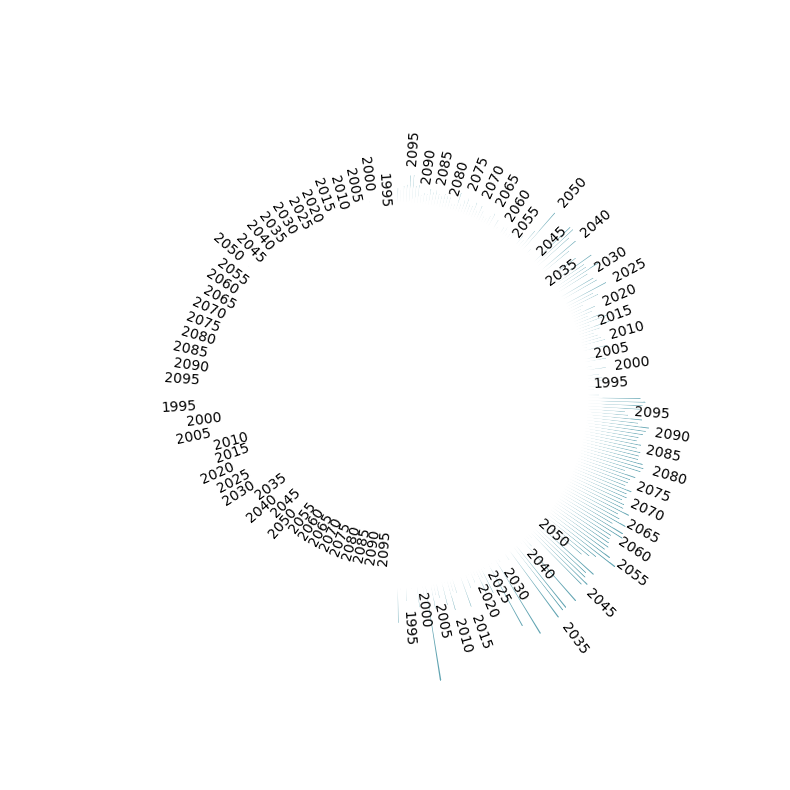

In [97]:
ANGLES = np.linspace(0, 2 * np.pi, len(df_an), endpoint=False)
VALUES = df_an["value"].values
LABELS = df_an["year"].values

# Determine the width of each bar. 
# The circumference is '2 * pi', so we divide that total width over the number of bars.
WIDTH = 2 * np.pi / len(VALUES)

# Determines where to place the first bar. 
# By default, matplotlib starts at 0 (the first bar is horizontal)
# but here we say we want to start at pi/2 (90 deg)
OFFSET = np.pi / 2

# Initialize Figure and Axis
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={"projection": "polar"})

# Specify offset
ax.set_theta_offset(OFFSET)

# Set limits for radial (y) axis. The negative lower bound creates the hole in the middle.
ax.set_ylim(-50, 100)

# Remove all spines
ax.set_frame_on(False)

# Remove grid and tick marks
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

# Add bars
ax.bar(
    ANGLES, VALUES, width=WIDTH, linewidth=2,
    color="#61a4b2", edgecolor="white"
)

# Add labels
add_labels(ANGLES, VALUES, LABELS, OFFSET, ax, 5)

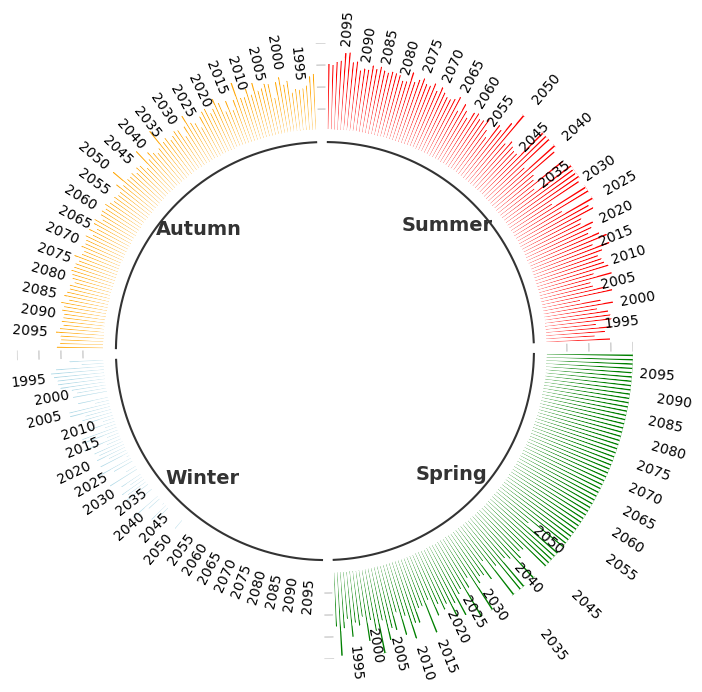

In [100]:
# All this part is like the code above
VALUES = df_an["value"].values
LABELS = df_an["year"].values
GROUP = df_an["group"].values

PAD = 3
ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP))
ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
WIDTH = (2 * np.pi) / len(ANGLES)

GROUPS_SIZE = [len(i[1]) for i in df_an.groupby("group")]

offset = 0
IDXS = []
for size in GROUPS_SIZE:
    IDXS += list(range(offset + PAD, offset + size + PAD))
    offset += size + PAD

fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={"projection": "polar"})
ax.set_theta_offset(OFFSET)
ax.set_ylim(-100, 40)
ax.set_frame_on(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

GROUPS_SIZE = [len(i[1]) for i in df_an.groupby("group")]
COLORS = ["orange"]*109 + ["lightblue"]*109+ ["green"]*109 + ["red"]*109
#COLORS = [f"C{i}" for i, size in enumerate(GROUPS_SIZE) for _ in range(size)]

ax.bar(
    ANGLES[IDXS], VALUES, width=WIDTH, color=COLORS, 
    edgecolor="white", linewidth=2
)

add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, ax)

# Extra customization below here --------------------

# This iterates over the sizes of the groups adding reference
# lines and annotations.

offset = 0 
for group, size in zip(["Autumn", "Winter", "Spring", "Summer"], GROUPS_SIZE):
    # Add line below bars
    x1 = np.linspace(ANGLES[offset + PAD], ANGLES[offset + size + PAD - 1], num=50)
    ax.plot(x1, [-5] * 50, color="#333333")
    
    # Add text to indicate group
    ax.text(
        np.mean(x1), -20, group, color="#333333", fontsize=14, 
        fontweight="bold", ha="center", va="center"
    )
    
    # Add reference lines at 10, 20, 30, and 40 %
    x2 = np.linspace(ANGLES[offset], ANGLES[offset + PAD - 1], num=50)
    ax.plot(x2, [10] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [20] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [30] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [40] * 50, color="#bebebe", lw=0.8)
    
    offset += size + PAD

In [99]:
GROUPS_SIZE

[109, 109, 109, 109]

### OK, the circular plot works but doesn't show the trend as well as the stacked bars and once Winter goes to zero Spring just looks wrong

In [101]:
seasons = np.unique(df_an.group.values)
seasons

array(['Autumn', 'Spring', 'Summer', 'Winter'], dtype=object)

In [102]:
for i,j in enumerate(seasons):
    print(i,j)

0 Autumn
1 Spring
2 Summer
3 Winter


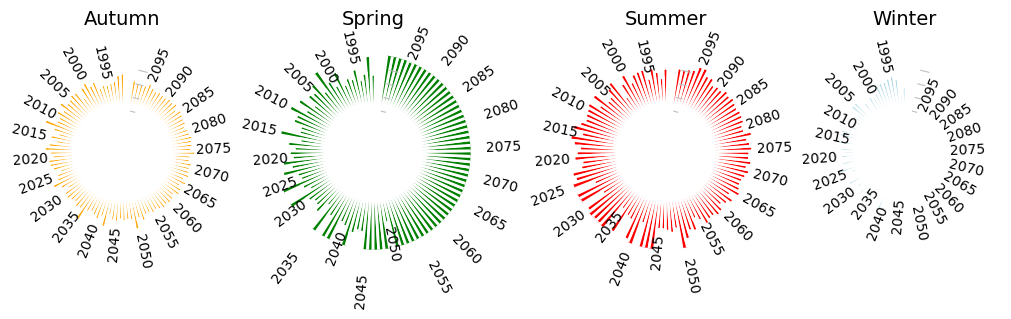

In [103]:
# one per season?

fig, axs = plt.subplots(1,4, figsize=(10,6), subplot_kw={"projection": "polar"}, layout='constrained')
axs = axs.flatten()

for i,j in enumerate(seasons):

    #ax = fig.add_subplot(2,2,i+1)
    df_tmp = df_an.query("group == @j")

    VALUES = df_tmp["value"].values
    LABELS = df_tmp["year"].values
    
    # 2 empty bars are added 
    PAD = 2
    ANGLES_N = len(VALUES) + PAD
    ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
    WIDTH = (2 * np.pi) / len(ANGLES)
    
    # The index contains non-empty bards
    IDXS = slice(0, ANGLES_N - PAD)
     
    #ANGLES = np.linspace(0, 2 * np.pi, len(df_tmp), endpoint=False)
    
    
    # Determine the width of each bar. 
    # The circumference is '2 * pi', so we divide that total width over the number of bars.
    #WIDTH = 2 * np.pi / len(VALUES)
    
    # Determines where to place the first bar. 
    # By default, matplotlib starts at 0 (the first bar is horizontal)
    # but here we say we want to start at pi/2 (90 deg)
    OFFSET = np.pi / 2
    
    # Specify offset
    axs[i].set_theta_offset(OFFSET)
    
    # Set limits for radial (y) axis. The negative lower bound creates the hole in the middle.
    axs[i].set_ylim(-30, 40)
    
    # Remove all spines
    axs[i].set_frame_on(False)
    
    # Remove grid and tick marks
    axs[i].xaxis.grid(False)
    axs[i].yaxis.grid(False)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

    COLORS = ["orange","green","red","lightblue"]
    
    # Add bars
    axs[i].bar(
        ANGLES[IDXS], VALUES, width=WIDTH, linewidth=2,
        color=COLORS[i], edgecolor="white"
    )
    
    # Add labels
    add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, axs[i])

    # Add reference lines at 0, 10, 20, and 30 %
    axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [0,0], color="#bebebe", lw=0.8)
    axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [10,10], color="#bebebe", lw=0.8)
    axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [20,20], color="#bebebe", lw=0.8)
    axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [30,30], color="#bebebe", lw=0.8)

    # title
    axs[i].set_title(j+"\n", fontsize=14)

### seems like it could be made better but the trends really don't come thru so moving on?
- maybe should make a function to do the four season circles for an input lat,lon and see

In [104]:
# function to create the seasonal circular bar plots for a given location

def CircularSeasonPlots(input_lat, input_lon):

    # build data frame
    ds_test = ds_canesm5_seasons.sel(lat=input_lat, lon=input_lon, method='nearest')
    ds_test = ds_test.sel(time=slice('1990','2100'))
    
    # create data for bar plot
    # get fraction of 365 days that are each season each year
    x = ds_test.time.dt.year.values
    
    AL = np.abs(ds_test.AutumnLength/365.0)
    WL = np.abs(ds_test.WinterLength/365.0)
    SpL = np.abs(ds_test.SpringLength/365.0)
    SL = np.abs(ds_test.SummerLength/365.0)
    sums = AL + WL + SpL + SL
    
    # normalize so each year has same total length and each season is a fraction of that year
    # multiply by 100 to get Pct
    ALn = AL/sums * 100
    WLn = WL/sums * 100
    SpLn = SpL/sums * 100
    SLn = SL/sums * 100
    
    # Build a dataset
    df = pd.DataFrame({
        "year": np.concatenate((x,x,x,x)),
        "value": np.concatenate((ALn, WLn, SpLn, SLn)),
        "group": ["Autumn"] * x.size + ["Winter"] * x.size + ["Spring"] * x.size + ["Summer"] * x.size
    })
    #print(df)

    # make plots
    fig, axs = plt.subplots(1,4, figsize=(10,5), subplot_kw={"projection": "polar"}, layout='constrained')
    axs = axs.flatten()
    plt.suptitle("Seasons for ["+str(input_lat)+","+str(input_lon)+"] (1990-2025)", fontsize=18)

    # season order by hemisphere
    if (input_lat >=0):
        seasons = ["Spring","Summer","Autumn","Winter"]
        COLORS = ["green","red", "orange","lightblue"]
    else:
        seasons = ["Autumn","Winter","Spring","Summer"]
        COLORS = ["orange","lightblue", "green","red"]
        
    #seasons = np.unique(df.group.values)
    
    for i,j in enumerate(seasons):
    
        #ax = fig.add_subplot(2,2,i+1)
        df_tmp = df.query("group == @j")

        VALUES = df_tmp["value"].values
        LABELS = df_tmp["year"].values
        
        # 2 empty bars are added to create a gap for the visual
        PAD = 2
        ANGLES_N = len(df_tmp) + PAD
        ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
        # Determine the width of each bar. 
        # The circumference is '2 * pi', so we divide that total width over the number of bars including PAD.
        WIDTH = (2 * np.pi) / len(ANGLES)
        
        # The index contains non-empty bards
        IDXS = slice(0, ANGLES_N - PAD)
        
        #ANGLES = np.linspace(0, 2 * np.pi, len(df_tmp), endpoint=False)
        
        
        # Determines where to place the first bar. 
        # By default, matplotlib starts at 0 (the first bar is horizontal)
        # but here we say we want to start at pi/2 (90 deg)
        OFFSET = np.pi / 2
        
        # Specify offset
        axs[i].set_theta_offset(OFFSET)
        
        # Set limits for radial (y) axis. The negative lower bound creates the hole in the middle.
        axs[i].set_ylim(-30, 40)
        
        # Remove all spines
        axs[i].set_frame_on(False)
        
        # Remove grid and tick marks
        axs[i].xaxis.grid(False)
        axs[i].yaxis.grid(False)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        
        # Add bars
        axs[i].bar(
            ANGLES[IDXS], VALUES, width=WIDTH, linewidth=2,
            color=COLORS[i], edgecolor="white"
        )
        
        # Add labels
        add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, axs[i])

        # Add reference lines at 0, 10, 20, and 30 %
        axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [0,0], color="#bebebe", lw=0.8)
        axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [10,10], color="#bebebe", lw=0.8)
        axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [20,20], color="#bebebe", lw=0.8)
        axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [30,30], color="#bebebe", lw=0.8)
    
        axs[i].set_title(j+"\n\n", fontsize=14)

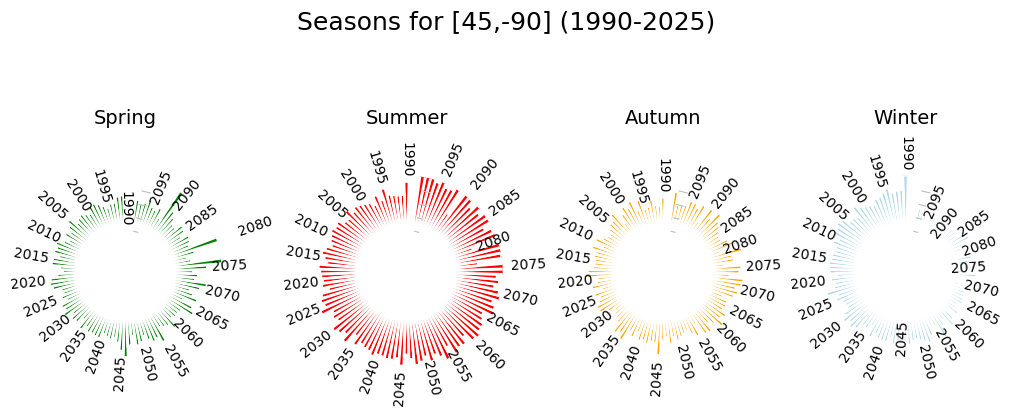

In [105]:
CircularSeasonPlots(45,-90)

In [106]:
# Toronto 43.6833	-79.6333
tor_lat = 43.6833
tor_lon = -79.6333

# Sydney
syd_lat = np.round(-33 - 52/60 - 4/3600, 3)
syd_lon = 151.25

# Vancouver
van_lat = 49.246
van_lon = -123.116

# Minneapolis
msp_lat = 45
msp_lon = -93.25

# Paris
par_lat = 48.7167
par_lon = 2.3842

#### Vancouver

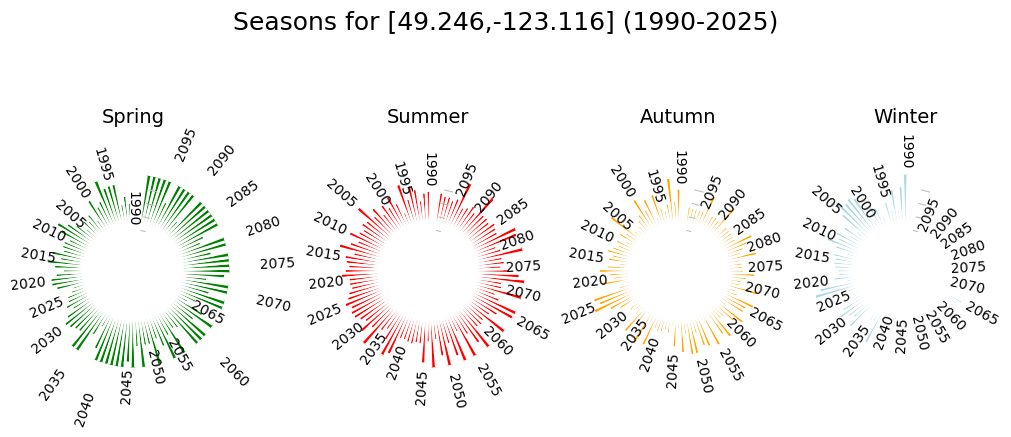

In [107]:
CircularSeasonPlots(van_lat,van_lon)

#### Sydney

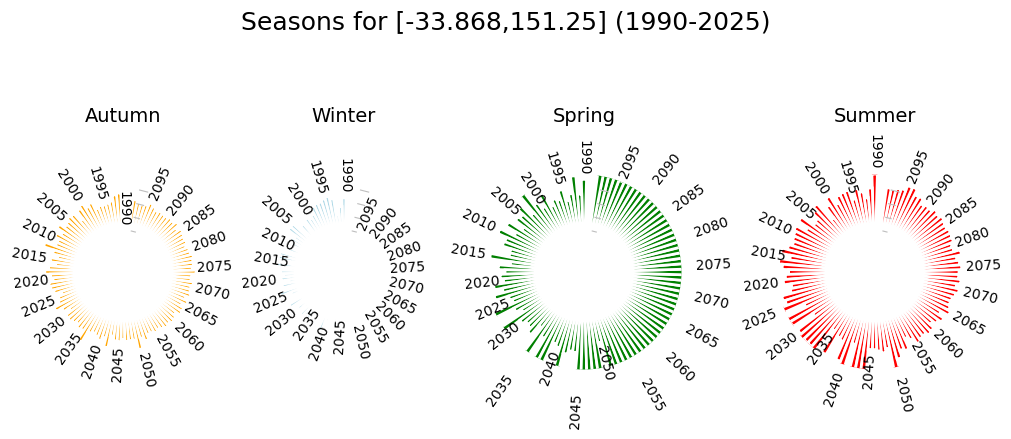

In [108]:
CircularSeasonPlots(syd_lat,syd_lon)

#### Minneapolis

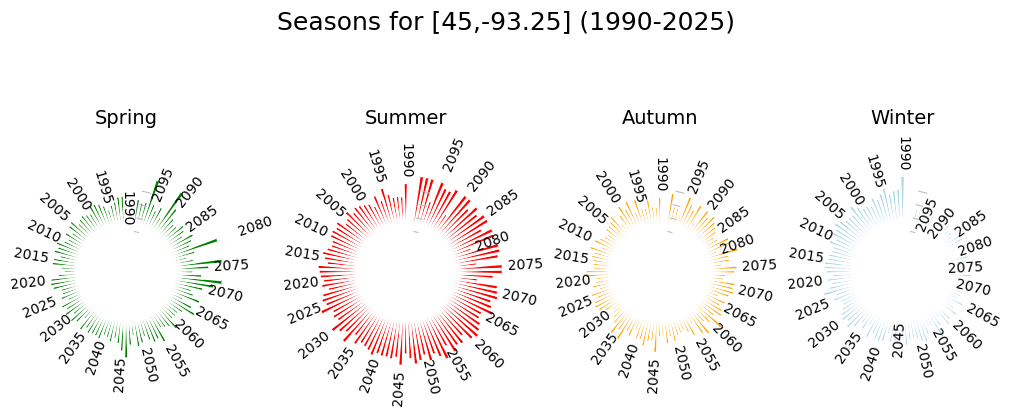

In [109]:
CircularSeasonPlots(msp_lat, msp_lon)

#### Paris

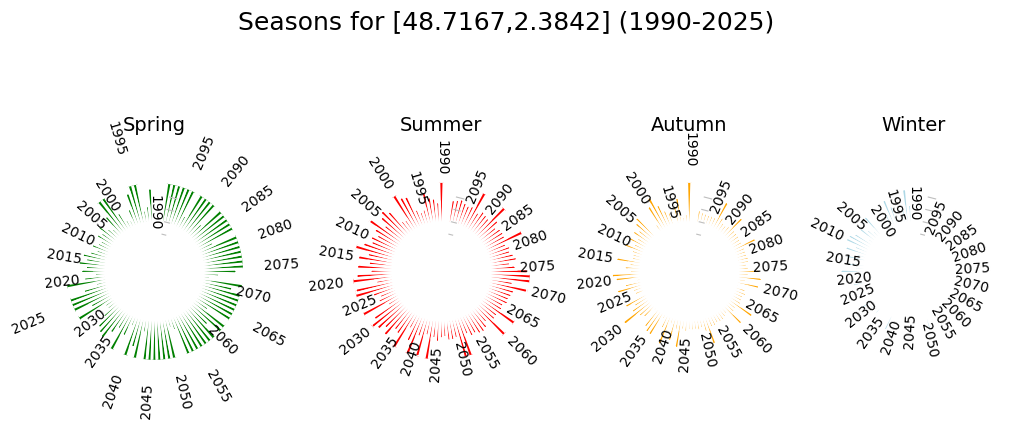

In [110]:
CircularSeasonPlots(par_lat, par_lon)

### Circular Barplots of Anomalies

In [111]:
nh_land_anom_5Y

<xarray.Dataset> Size: 924B
Dimensions:       (time: 23)
Coordinates:
  * time          (time) datetime64[ns] 184B 1990-12-31 ... 2100-12-31
    type          |S4 4B b'land'
Data variables:
    WinterLength  (time) float64 184B 2.161 11.97 2.943 ... -64.41 -62.77 -68.12
    SummerLength  (time) float64 184B -8.314 -9.236 -4.228 ... 38.28 41.33 39.09
    SpringLength  (time) float64 184B -93.5 -2.653 -3.914 ... 116.6 111.3 128.3
    AutumnLength  (time) float64 184B 9.174 0.1031 2.437 ... -87.26 -111.4

In [112]:
# create data for bar plot
# start at 1966
nh_land_anom_5Y_p = nh_land_anom_5Y.sel(time=slice('1991','2099'))

yrs = nh_land_anom_5Y_p.time.dt.year.values

# Build a dataset
df_anom = pd.DataFrame({
    "year": np.concatenate((yrs,yrs,yrs,yrs)),
    "value": np.concatenate((nh_land_anom_5Y_p.AutumnLength, nh_land_anom_5Y_p.WinterLength, nh_land_anom_5Y_p.SpringLength, nh_land_anom_5Y_p.SummerLength)),
    "group": ["Autumn"] * yrs.size + ["Winter"] * yrs.size + ["Spring"] * yrs.size + ["Summer"] * yrs.size
})

# Show 3 first rows
df_anom

,year,value,group
0,1995,0.103053,Autumn
1,2000,2.437149,Autumn
2,2005,0.946401,Autumn
3,2010,0.399444,Autumn
4,2015,-2.250833,Autumn
...,...,...,...
79,2075,34.465601,Summer
80,2080,35.102867,Summer
81,2085,37.322132,Summer
82,2090,38.280094,Summer


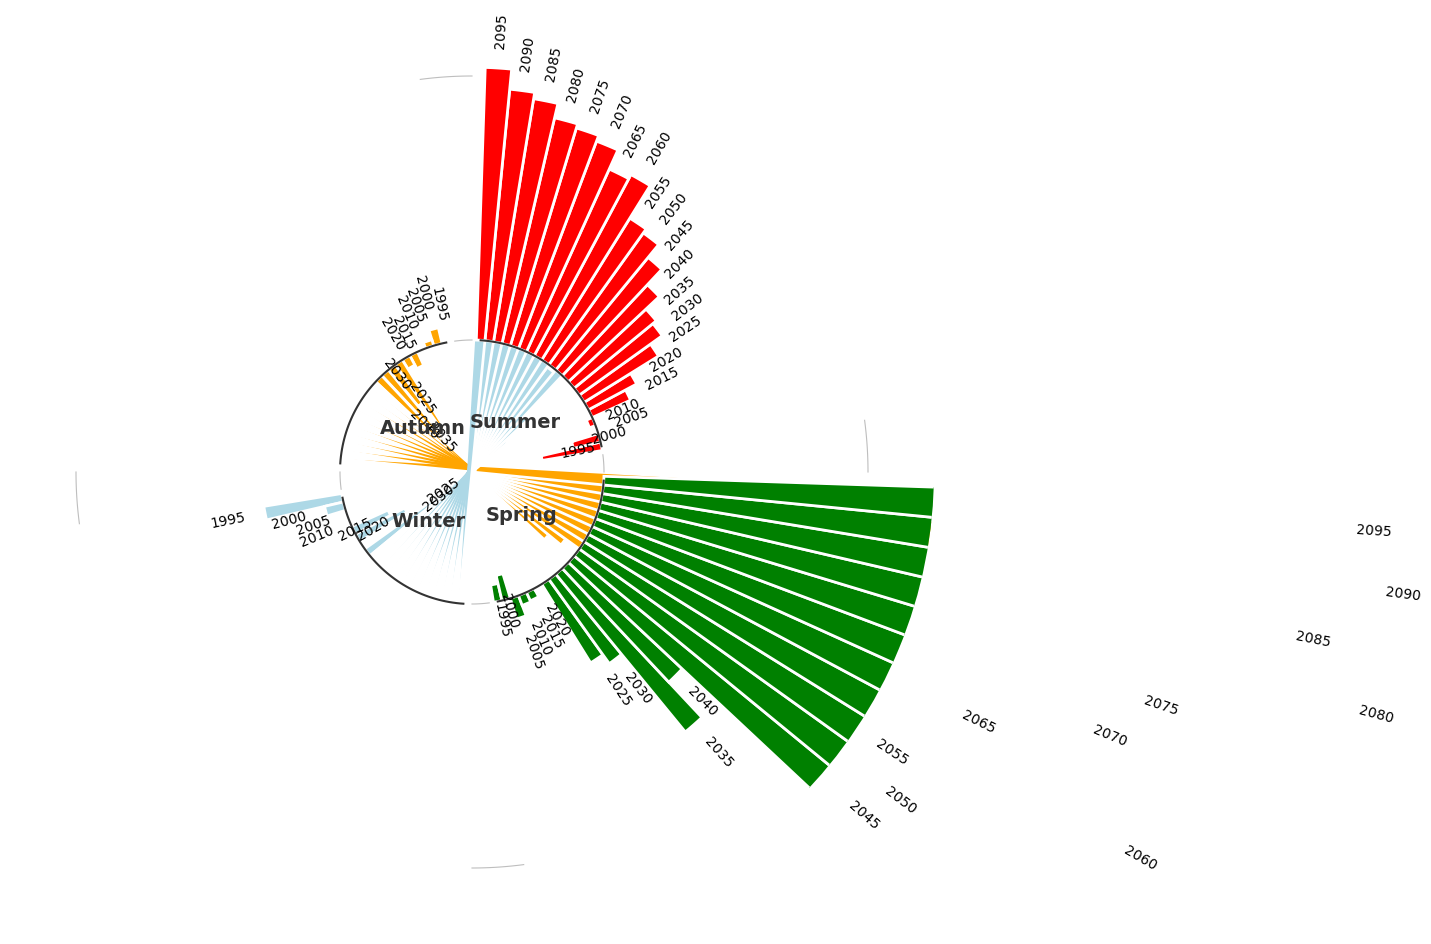

In [120]:
# All this part is like the code above
VALUES = df_anom["value"].values
LABELS = df_anom["year"].values
GROUP = df_anom["group"].values

PAD = 3
ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP))
ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
WIDTH = (2 * np.pi) / len(ANGLES)

GROUPS_SIZE = [len(i[1]) for i in df_anom.groupby("group")]

offset = 0
IDXS = []
for size in GROUPS_SIZE:
    IDXS += list(range(offset + PAD, offset + size + PAD))
    offset += size + PAD

fig, ax = plt.subplots(figsize=(18, 12), subplot_kw={"projection": "polar"})
#plt.suptitle("NH Land Season Length 5Y Anomaly from 1961-1990 Mean\n\n")
#plt.title("\n")
ax.set_theta_offset(OFFSET)
ax.set_ylim(-20, 50)
ax.set_frame_on(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

GROUPS_SIZE = [len(i[1]) for i in df_anom.groupby("group")]
n_bars = GROUPS_SIZE[0]
COLORS = ["orange"]*n_bars + ["lightblue"]*n_bars+ ["green"]*n_bars + ["red"]*n_bars
#COLORS = [f"C{i}" for i, size in enumerate(GROUPS_SIZE) for _ in range(size)]

ax.bar(
    ANGLES[IDXS], VALUES, width=WIDTH, color=COLORS, 
    edgecolor="white", linewidth=2
)

add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, ax, 5)

# Extra customization below here --------------------

# This iterates over the sizes of the groups adding reference
# lines and annotations.

offset = 0 
for group, size in zip(["Autumn", "Winter", "Spring", "Summer"], GROUPS_SIZE):
    # Add line below bars
    x1 = np.linspace(ANGLES[offset + PAD], ANGLES[offset + size + PAD - 1], num=50)
    ax.plot(x1, [0] * 50, color="#333333")
    
    # Add text to indicate group
    ax.text(
        np.mean(x1), -10, group, color="#333333", fontsize=14, 
        fontweight="bold", ha="center", va="center"
    )
    
    # Add reference lines at 10, 20, 30, and 40 %
    x2 = np.linspace(ANGLES[offset], ANGLES[offset + PAD - 1], num=50)
    ax.plot(x2, [-40] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [0] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [40] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [80] * 50, color="#bebebe", lw=0.8)
    
    offset += size + PAD

## Circular for anomalies doesn't really work - not sure why there is overlap but the horizontal barplot is likely to be better anyway so moving on

### Barplots of anomalies and season lengths

Text(0, 0.5, 'Length [Days]')

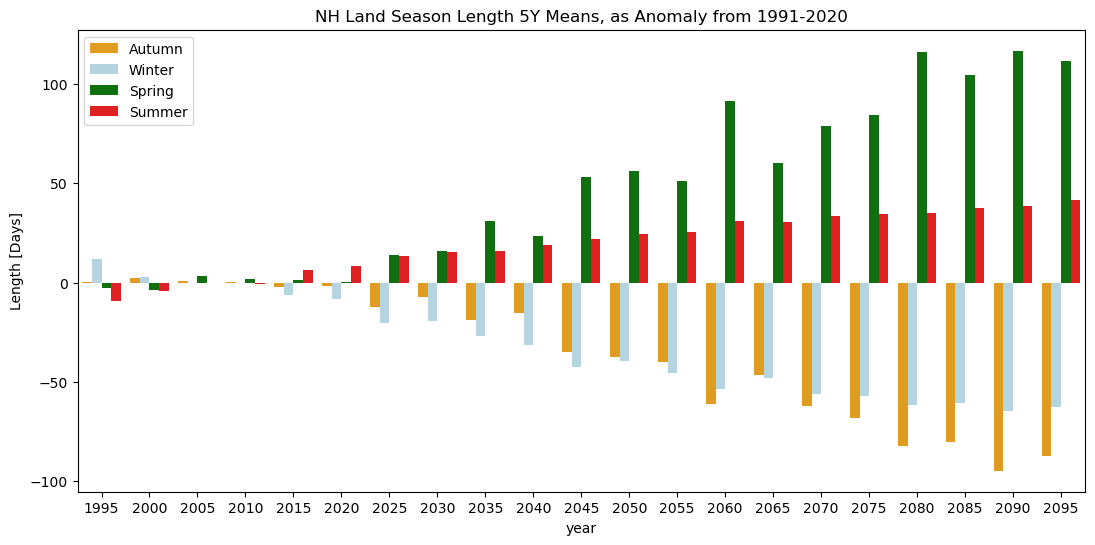

In [148]:
# got rid of legend title following https://stackoverflow.com/questions/51579215/remove-seaborn-lineplot-legend-title
plt.figure(figsize=(13,6))
sns.barplot(x="year", y="value", hue=df_anom["group"].to_list(), data=df_anom, palette=["orange","lightblue","green","red"])
plt.title("NH Land Season Length 5Y Means, as Anomaly from 1991-2020")
plt.ylabel("Length [Days]")